# STAT3612: Multimodal Brain Tumor Classification — Full Pipeline

This notebook implements the **three-stage pipeline** described in our proposal:

| Section | Proposal Stage | Content |
|---|---|---|
| **0. Setup & EDA** | Preliminary Findings | Environment, data loading, EDA findings (class imbalance, missing data, multimodal incompleteness) |
| **1. Feature Engineering** | Data Processing | Load & encode all 4 modalities; PCA; standardize |
| **2. Single-Modality Baselines** | Stage 1 | Independent classifiers per modality to understand individual contributions |
| **3. Multimodal Fusion** | Stage 2 | Early fusion (concatenated features) and late fusion (voting/stacking) |
| **4. Optimization** | Stage 3 | Feature selection, PCA sweep, SVM/XGB tuning (Section 4.1) |
| **5. Model Analysis** | Analysis Plan | Model comparison, modality ablation, interpretability |
| **6. Kaggle Submission** | — | Generate final submission file |

**Primary evaluation metric**: **Macro-F1** (aligned with Kaggle leaderboard F1 scoring)  
**Secondary metrics**: Weighted-F1, Accuracy, Per-class Precision/Recall/F1  
**5-class target**: Glioma, Meningioma, Brain Metastase Tumour, Tumors of the sellar region, Pineal tumour and Choroid plexus tumour

---
# 0. Setup & Exploratory Data Analysis

## 0.1 Environment

In [2]:
import copy
import json, os, warnings
from collections import Counter
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import xgboost as xgb
from torch import nn
from torch.utils.data import DataLoader, Dataset

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score

sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

def _find_train_val_root() -> Path:
    """Locate folder containing train.json + val.json (dataset/kaggle-dataset or ./kaggle-dataset)."""
    names = ('dataset/kaggle-dataset', 'kaggle-dataset')

    def _try_pair(base: Path) -> Path | None:
        base = base.resolve()
        for name in names:
            p = base / name
            if (p / 'train.json').is_file() and (p / 'val.json').is_file():
                return p
        if (base / 'train.json').is_file() and (base / 'val.json').is_file():
            return base
        return None

    seen: set[Path] = set()
    search_order: list[Path] = []

    for key in ('STAT3612_TRAIN_VAL_DIR', 'STAT3612_DATA_ROOT', 'KAGGLE_DATA_ROOT'):
        v = os.environ.get(key, '').strip()
        if v:
            search_order.append(Path(v).expanduser())

    search_order.append(Path.cwd())
    kin = Path('/kaggle/input')
    if kin.is_dir():
        for sub in sorted(kin.iterdir()):
            if sub.is_dir():
                search_order.append(sub)

    for start in search_order:
        try:
            start = start.resolve()
        except OSError:
            continue
        for d in [start, *start.parents]:
            if d in seen:
                continue
            seen.add(d)
            hit = _try_pair(d)
            if hit is not None:
                return hit

    cwd = Path.cwd()
    raise FileNotFoundError(
        'Cannot find train.json and val.json.\n'
        f'  cwd = {cwd}\n'
        '  Fix: (1) os.chdir("/path/to/STAT3612-Amateur-Neuro-Team") before this cell, or\n'
        '  (2) set env STAT3612_TRAIN_VAL_DIR to the folder containing train.json and val.json.\n'
        '  See dataset/README.md.'
    )


def _find_test_root(train_val: Path) -> Path:
    """Monolithic layout: test.json next to train. Split layout: sibling new_test/test.json."""
    if (train_val / 'test.json').is_file():
        return train_val.resolve()
    cand = train_val.parent / 'new_test' / 'test.json'
    if cand.is_file():
        return cand.parent.resolve()
    raise FileNotFoundError(
        f'Cannot find test.json next to {train_val} or at {cand}. See dataset/README.md.'
    )


TRAIN_VAL_ROOT = _find_train_val_root()
TEST_ROOT = _find_test_root(TRAIN_VAL_ROOT)
BASE_DIR = str(TRAIN_VAL_ROOT)
print('TRAIN_VAL_ROOT =', TRAIN_VAL_ROOT)
print('TEST_ROOT =', TEST_ROOT)

FileNotFoundError: Cannot find train.json and val.json.
  cwd = /content
  Fix: (1) os.chdir("/path/to/STAT3612-Amateur-Neuro-Team") before this cell, or
  (2) set env STAT3612_TRAIN_VAL_DIR to the folder containing train.json and val.json.
  See dataset/README.md.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0.2 Load Metadata

In [ ]:
with open(TRAIN_VAL_ROOT / 'train.json') as f:
    train_meta = json.load(f)
with open(TRAIN_VAL_ROOT / 'val.json') as f:
    val_meta = json.load(f)
with open(TEST_ROOT / 'test.json') as f:
    test_meta = json.load(f)

print(f'Splits — Train: {len(train_meta)}, Val: {len(val_meta)}, Test: {len(test_meta)}')

train_labels = {k: v['Overall_class'] for k, v in train_meta.items()}
val_labels   = {k: v['Overall_class'] for k, v in val_meta.items()}

Splits — Train: 1983, Val: 283, Test: 378


## 0.3 EDA: Class Imbalance (~40:1)

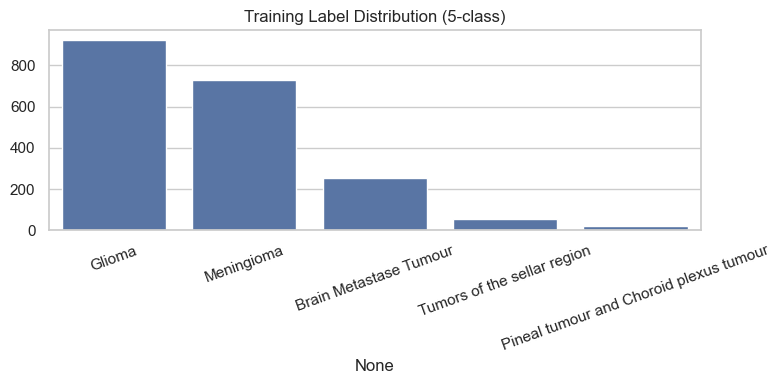

Class frequencies:
  Glioma: 924 (46.6%)
  Meningioma: 728 (36.7%)
  Brain Metastase Tumour: 252 (12.7%)
  Tumors of the sellar region: 56 (2.8%)
  Pineal tumour and Choroid plexus tumour: 23 (1.2%)

Imbalance ratio (max/min): 40:1


In [ ]:
label_counts = pd.Series(Counter(train_labels.values())).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, ax=ax)
ax.set_title('Training Label Distribution (5-class)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

print('Class frequencies:')
for cls, cnt in label_counts.items():
    print(f'  {cls}: {cnt} ({cnt/len(train_labels)*100:.1f}%)')
print(f'\nImbalance ratio (max/min): {label_counts.max()/label_counts.min():.0f}:1')

## 0.4 EDA: Multimodal Incompleteness (~20% missing 1 modality)

In [ ]:
MODALITIES = ['ax_t1', 'ax_t1c', 'ax_t2', 'ax_t2f']

for split_name, meta in [('train', train_meta), ('val', val_meta), ('test', test_meta)]:
    n_paths = [len(v.get('image_path', [])) for v in meta.values()]
    counts = Counter(n_paths)
    total = len(meta)
    print(f'[{split_name}] modality completeness: ', end='')
    for k in sorted(counts):
        print(f'{k}-mod={counts[k]} ({counts[k]/total*100:.1f}%)  ', end='')
    print()

[train] modality completeness: 3-mod=390 (19.7%)  4-mod=1593 (80.3%)  
[val] modality completeness: 3-mod=61 (21.6%)  4-mod=222 (78.4%)  
[test] modality completeness: 1-mod=10 (2.6%)  2-mod=9 (2.4%)  3-mod=81 (21.4%)  4-mod=278 (73.5%)  


## 0.5 EDA: Missing Demographics (JSON ~70% vs CSV ~0%)

In [ ]:
def _clean_cols(df):
    df.columns = [str(c).replace(chr(0xFEFF), '').strip() for c in df.columns]
    return df

clin_train = _clean_cols(pd.read_csv(os.path.join(BASE_DIR, 'clinical_information', 'train_patient_info.csv')))

json_age_missing = sum(1 for v in train_meta.values() if not v.get('Age'))
json_sex_missing = sum(1 for v in train_meta.values() if not v.get('Sex'))
clin_age_missing = clin_train['Age'].isna().sum()
clin_sex_missing = clin_train['Sex'].isna().sum()

print(f'JSON  Age missing: {json_age_missing}/{len(train_meta)} ({json_age_missing/len(train_meta)*100:.1f}%)')
print(f'JSON  Sex missing: {json_sex_missing}/{len(train_meta)} ({json_sex_missing/len(train_meta)*100:.1f}%)')
print(f'CSV   Age missing: {clin_age_missing}/{len(clin_train)} ({clin_age_missing/len(clin_train)*100:.1f}%)')
print(f'CSV   Sex missing: {clin_sex_missing}/{len(clin_train)} ({clin_sex_missing/len(clin_train)*100:.1f}%)')
print('\n=> Clinical CSV is the preferred source for demographics.')

JSON  Age missing: 1380/1983 (69.6%)
JSON  Sex missing: 1380/1983 (69.6%)
CSV   Age missing: 1384/1983 (69.8%)
CSV   Sex missing: 0/1983 (0.0%)

=> Clinical CSV is the preferred source for demographics.


## 0.6 EDA: Radiomics Feature Correlation

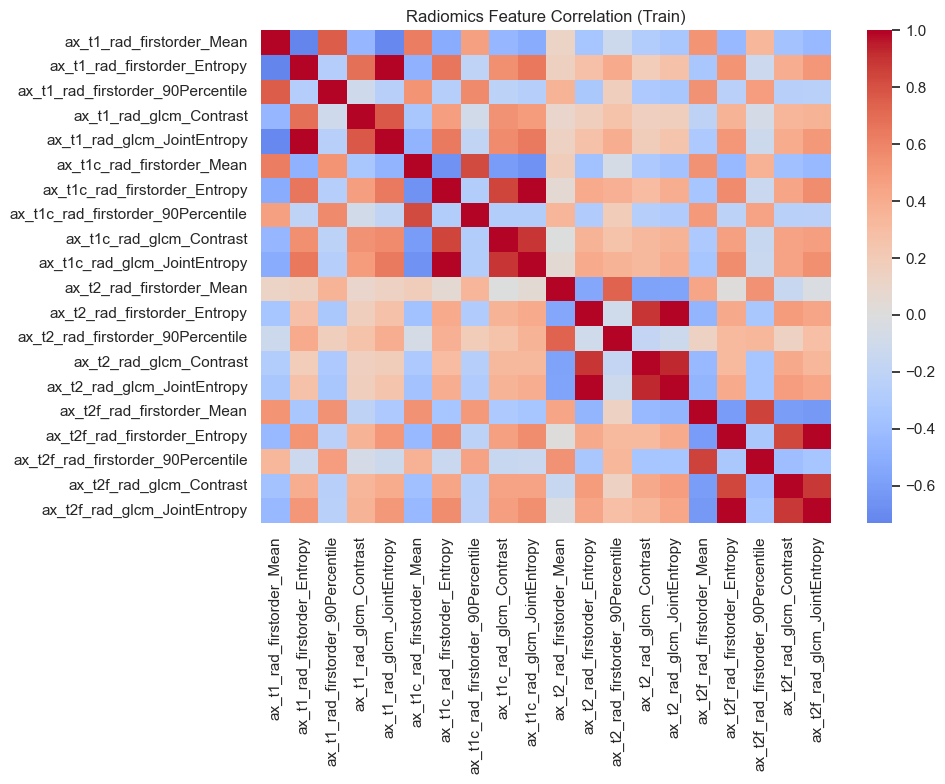

Feature pairs with |r| > 0.95: 4


In [ ]:
RADIOMICS_FEAT_COLS = ['rad_firstorder_Mean', 'rad_firstorder_Entropy',
                       'rad_firstorder_90Percentile', 'rad_glcm_Contrast',
                       'rad_glcm_JointEntropy']

rad_frames = []
for mod in MODALITIES:
    df = _clean_cols(pd.read_csv(os.path.join(BASE_DIR, 'radiomics_info', 'train', f'{mod}_radiomics_train.csv')))
    for c in RADIOMICS_FEAT_COLS:
        df = df.rename(columns={c: f'{mod}_{c}'})
    rad_frames.append(df)

rad_all = rad_frames[0][['case_id']].copy()
for df in rad_frames:
    rad_all = rad_all.merge(df.drop(columns=['sex','age','modality'], errors='ignore'), on='case_id', how='left')

rad_numeric = rad_all.select_dtypes(include=[np.number]).drop(columns=['case_id'], errors='ignore')
corr = rad_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, xticklabels=True, yticklabels=True)
plt.title('Radiomics Feature Correlation (Train)')
plt.tight_layout(); plt.show()

high_corr = (corr.abs() > 0.95).sum().sum() - len(corr)
print(f'Feature pairs with |r| > 0.95: {high_corr // 2}')

---
# 1. Feature Engineering

We load and encode all four modalities, then combine them into a unified feature matrix.

## 1.1 Image Features (2048-d × 4 modalities, zero-pad if missing)

In [ ]:
def load_image_features(meta_dict, base_dir=None):
    if base_dir is None:
        base_dir = str(TRAIN_VAL_ROOT)
    case_ids = sorted(meta_dict.keys(), key=int)
    features = []
    for cid in case_ids:
        case_feats = []
        for mod in MODALITIES:
            npy_path = os.path.join(base_dir, 'image_features', 'image_features', cid, mod, 'image.npy')
            if os.path.exists(npy_path):
                case_feats.append(np.load(npy_path))
            else:
                case_feats.append(np.zeros(2048, dtype=np.float32))
        features.append(np.concatenate(case_feats))
    return np.array(features), case_ids

X_img_train, train_ids = load_image_features(train_meta)
X_img_val,   val_ids   = load_image_features(val_meta)
X_img_test,  test_ids  = load_image_features(test_meta, str(TEST_ROOT))
print(f'Image — Train: {X_img_train.shape}, Val: {X_img_val.shape}, Test: {X_img_test.shape}')

Image — Train: (1983, 8192), Val: (283, 8192), Test: (378, 8192)


## 1.2 Radiomics Features (5 × 4 modalities, NaN → 0)

In [ ]:
def load_radiomics(split, case_ids, base_dir=None):
    if base_dir is None:
        base_dir = str(TEST_ROOT if split == 'test' else TRAIN_VAL_ROOT)
    all_feats = pd.DataFrame({'case_id': [int(c) for c in case_ids]})
    for mod in MODALITIES:
        df = _clean_cols(pd.read_csv(os.path.join(base_dir, 'radiomics_info', split, f'{mod}_radiomics_{split}.csv')))
        rename = {c: f'{mod}_{c}' for c in RADIOMICS_FEAT_COLS}
        df = df[['case_id'] + RADIOMICS_FEAT_COLS].rename(columns=rename)
        all_feats = all_feats.merge(df, on='case_id', how='left')
    feat_cols = [c for c in all_feats.columns if c != 'case_id']
    all_feats[feat_cols] = all_feats[feat_cols].fillna(0)
    all_feats = all_feats.set_index('case_id').loc[[int(c) for c in case_ids]]
    return all_feats.values

X_rad_train = load_radiomics('train', train_ids)
X_rad_val   = load_radiomics('val',   val_ids)
X_rad_test  = load_radiomics('test',  test_ids)
print(f'Radiomics — Train: {X_rad_train.shape}, Val: {X_rad_val.shape}, Test: {X_rad_test.shape}')

Radiomics — Train: (1983, 20), Val: (283, 20), Test: (378, 20)


## 1.3 Clinical Features (from CSV; demographics sourced from clinical_information)

In [ ]:
def _clinical_csv_path(split: str, base_dir: str) -> str:
    root = Path(base_dir)
    flat = root / 'clinical_information' / f'{split}_patient_info.csv'
    nested = root / 'clinical_information' / split / f'{split}_patient_info.csv'
    if nested.is_file():
        return str(nested)
    if flat.is_file():
        return str(flat)
    raise FileNotFoundError(
        f'Could not find clinical CSV for split={split!r} under {base_dir} (tried {nested} and {flat}).'
    )


def load_clinical(split, case_ids, base_dir=None):
    if base_dir is None:
        base_dir = str(TEST_ROOT if split == 'test' else TRAIN_VAL_ROOT)
    df = _clean_cols(pd.read_csv(_clinical_csv_path(split, base_dir)))
    df = df.set_index('case_id').loc[[int(c) for c in case_ids]].reset_index()
    return df

df_clin_train = load_clinical('train', train_ids)
df_clin_val   = load_clinical('val',   val_ids)
df_clin_test  = load_clinical('test',  test_ids)

sex_map = {'female': 0, 'male': 1, 'unknown': 2}
for df in [df_clin_train, df_clin_val, df_clin_test]:
    df['Sex_enc'] = df['Sex'].map(sex_map)

train_age_median = df_clin_train['Age'].median()
for df in [df_clin_train, df_clin_val, df_clin_test]:
    df['Age_filled'] = df['Age'].fillna(train_age_median)

intensity_map = {'hypointense': 0, 'isointense': 1, 'hyperintense': 2,
                 'heterogeneous': 3, 'homogeneous': 4, 'unknown': 5}
intensity_cols = ['Signal Intensity (T1)', 'Signal Intensity (T1c)',
                  'Signal Intensity (T2)', 'Signal Intensity (T2-FLAIR)']
for df in [df_clin_train, df_clin_val, df_clin_test]:
    for col in intensity_cols:
        df[col + '_enc'] = df[col].map(intensity_map).fillna(5).astype(int)

location_keywords = ['frontal', 'temporal', 'parietal', 'occipital', 'cerebellum',
                     'sellar', 'sella', 'pituitary', 'pineal', 'ventricle',
                     'brainstem', 'cerebellopontine', 'thalamus', 'basal',
                     'left', 'right', 'bilateral', 'midline']
for df in [df_clin_train, df_clin_val, df_clin_test]:
    loc_lower = df['Tumor Location'].str.lower().fillna('')
    for kw in location_keywords:
        df[f'loc_{kw}'] = loc_lower.str.contains(kw).astype(int)

clinical_feat_cols = (['Sex_enc', 'Age_filled'] +
                      [c + '_enc' for c in intensity_cols] +
                      [f'loc_{kw}' for kw in location_keywords])

X_clin_train = df_clin_train[clinical_feat_cols].values.astype(float)
X_clin_val   = df_clin_val[clinical_feat_cols].values.astype(float)
X_clin_test  = df_clin_test[clinical_feat_cols].values.astype(float)
print(f'Clinical — Train: {X_clin_train.shape}, Val: {X_clin_val.shape}, Test: {X_clin_test.shape}')

Clinical — Train: (1983, 24), Val: (283, 24), Test: (378, 24)


## 1.4 Text Features (TF-IDF from radiology reports)

In [ ]:
def _report_to_text(report):
    if isinstance(report, str):
        return report
    if isinstance(report, dict):
        parts = [str(report.get(k, '')).strip() for k in ['finding', 'impression'] if report.get(k)]
        if not parts:
            parts = [str(v).strip() for v in report.values() if v]
        return ' '.join(parts)
    if isinstance(report, list):
        return ' '.join(_report_to_text(x) for x in report if x).strip()
    return '' if report is None else str(report)


def get_reports(meta_dict, case_ids):
    return [_report_to_text(meta_dict[c].get('report', '')) for c in case_ids]


tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2), stop_words='english', min_df=3)
X_text_train = tfidf.fit_transform(get_reports(train_meta, train_ids)).toarray()
X_text_val   = tfidf.transform(get_reports(val_meta, val_ids)).toarray()
X_text_test  = tfidf.transform(get_reports(test_meta, test_ids)).toarray()
print(f'Text — Train: {X_text_train.shape}, Val: {X_text_val.shape}, Test: {X_text_test.shape}')

Text — Train: (1983, 500), Val: (283, 500), Test: (378, 500)


## 1.5 PCA, Standardize, Encode Labels

In [ ]:
pca_img = PCA(n_components=256, random_state=SEED)
X_img_train_pca = pca_img.fit_transform(X_img_train)
X_img_val_pca   = pca_img.transform(X_img_val)
X_img_test_pca  = pca_img.transform(X_img_test)
print(f'PCA explained variance (256 comp): {pca_img.explained_variance_ratio_.sum():.4f}')

# Early-fusion feature matrix
X_train_all = np.hstack([X_img_train_pca, X_rad_train, X_clin_train, X_text_train])
X_val_all   = np.hstack([X_img_val_pca,   X_rad_val,   X_clin_val,   X_text_val])
X_test_all  = np.hstack([X_img_test_pca,  X_rad_test,  X_clin_test,  X_text_test])
print(f'Early-fusion features: {X_train_all.shape[1]}d (img 256 + rad {X_rad_train.shape[1]} + clin {X_clin_train.shape[1]} + text {X_text_train.shape[1]})')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_val_scaled   = scaler.transform(X_val_all)
X_test_scaled  = scaler.transform(X_test_all)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform([train_labels[c] for c in train_ids])
y_val   = label_encoder.transform([val_labels[c] for c in val_ids])
print(f'Labels: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}')

# Class weights for imbalance handling
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
sample_weights_train = np.array([class_weight_dict[y] for y in y_train])
for idx, w in class_weight_dict.items():
    print(f'  {label_encoder.inverse_transform([idx])[0]}: weight={w:.3f}')

PCA explained variance (256 comp): 0.9218
Early-fusion features: 800d (img 256 + rad 20 + clin 24 + text 500)
Labels: {'Brain Metastase Tumour': 0, 'Glioma': 1, 'Meningioma': 2, 'Pineal tumour and Choroid plexus tumour': 3, 'Tumors of the sellar region': 4}
  Brain Metastase Tumour: weight=1.574
  Glioma: weight=0.429
  Meningioma: weight=0.545
  Pineal tumour and Choroid plexus tumour: weight=17.243
  Tumors of the sellar region: weight=7.082


---
# 2. Stage 1 — Single-Modality Baselines

Before fusion, we evaluate each modality independently to understand its discriminative power. This directly informs which modalities are worth fusing and which fusion strategy to use.

**Methodology (Lecture 4.1 — Cross-Validation)**:

For each modality we follow a two-step evaluation protocol:

1. **Primary**: **Stratified 5-fold CV on the training set** — produces `mean ± std` Macro-F1 across folds. This is the number we use for **model selection**, because it captures generalization variance.
2. **Reference**: **Held-out `val.json` evaluation** — a single-point estimate on data never seen during CV or training. Used to confirm that CV results transfer.

After CV-based selection, we **retrain the chosen model on the full training set** and report the held-out metrics.

**Evaluation metrics** (aligned with Kaggle & proposal):

| Metric | Role | Rationale |
|---|---|---|
| **Macro-F1** | **Primary** | Treats all 5 classes equally; directly penalizes poor minority-class recall — critical given ~40:1 class imbalance. This is the metric we optimize toward. |
| **Weighted-F1** | Secondary | Weights each class by support; reflects overall sample-level performance. |
| **Accuracy** | Reference | Easy to interpret but misleading under class imbalance (a model predicting only Glioma/Meningioma can achieve >80% accuracy). |
| **Per-class Precision / Recall / F1** | Diagnostic | Identifies which specific tumor types are under-served by each modality. |

> **Note on Kaggle scoring**: The competition leaderboard uses **F1 score**. Since our task is multiclass (5 classes), the Kaggle F1 is computed as **macro-averaged F1** across all classes. Our primary metric (Macro-F1) is therefore directly aligned with the competition evaluation.

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def eval_modality(X_tr, X_va, y_tr, y_va, name, model=None):
    """
    Two-step evaluation per Lecture 4.1:
      1. Stratified 5-fold CV on training set  →  primary (model selection)
      2. Retrain on full training set → eval on held-out val  →  reference
    """
    if model is None:
        model = lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                                   class_weight='balanced', random_state=SEED, verbose=-1)

    # ── Step 1: 5-fold CV on training set (primary evaluation) ──
    cv_pipe = make_pipeline(StandardScaler(), clone(model))
    cv_scores = cross_val_score(cv_pipe, X_tr, y_tr, cv=skf, scoring='f1_macro', n_jobs=-1)

    # ── Step 2: Retrain on full training set → held-out val (reference) ──
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_va_s = sc.transform(X_va)
    model.fit(X_tr_s, y_tr)
    y_pred = model.predict(X_va_s)

    acc = accuracy_score(y_va, y_pred)
    f1_macro = f1_score(y_va, y_pred, average='macro')
    f1_weighted = f1_score(y_va, y_pred, average='weighted')

    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    print(f'  [CV]      Macro-F1 = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  '
          f'(folds: {", ".join(f"{s:.3f}" for s in cv_scores)})')
    print(f'  [Val]     Macro-F1 = {f1_macro:.4f}  |  Accuracy = {acc:.4f}  |  '
          f'Weighted-F1 = {f1_weighted:.4f}')
    print(f'\nClassification Report (held-out val):')
    print(classification_report(y_va, y_pred,
                                target_names=label_encoder.classes_, digits=4))

    return {'accuracy': acc, 'macro_f1': f1_macro, 'weighted_f1': f1_weighted,
            'cv_scores': cv_scores, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
            'y_pred': y_pred, 'model': model, 'scaler': sc}

# ── Run all four modalities ──
print('=' * 60)
print('  Stage 1 — Single-Modality Baselines (LightGBM)')
print('  Evaluation: 5-Fold CV (primary) + Held-out Val (reference)')
print('=' * 60)

single_detail = {}
single_models = {}
single_scalers = {}

for mod_name, Xtr, Xva in [
    ('Image (PCA-256)',    X_img_train_pca, X_img_val_pca),
    ('Radiomics (20-d)',   X_rad_train,     X_rad_val),
    ('Clinical (24-d)',    X_clin_train,    X_clin_val),
    ('Text (TF-IDF 500)', X_text_train,    X_text_val),
]:
    res = eval_modality(Xtr, Xva, y_train, y_val, mod_name)
    single_detail[mod_name] = res
    single_models[mod_name] = res['model']
    single_scalers[mod_name] = res['scaler']

single_results = {k: v['macro_f1'] for k, v in single_detail.items()}

  Stage 1 — Single-Modality Baselines (LightGBM)
  Evaluation: 5-Fold CV (primary) + Held-out Val (reference)


/opt/anaconda3/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:13: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/opt/anaconda3/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:13: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/opt/anaconda3/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:13: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/opt/anaconda3/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:13: Fu


  Image (PCA-256)
  [CV]      Macro-F1 = 0.2787 ± 0.0209  (folds: 0.262, 0.269, 0.319, 0.279, 0.263)
  [Val]     Macro-F1 = 0.2999  |  Accuracy = 0.6113  |  Weighted-F1 = 0.5749

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.4444    0.1111    0.1778        36
                                 Glioma     0.6111    0.7500    0.6735       132
                             Meningioma     0.6250    0.6731    0.6481       104
Pineal tumour and Choroid plexus tumour     0.0000    0.0000    0.0000         3
            Tumors of the sellar region     0.0000    0.0000    0.0000         8

                               accuracy                         0.6113       283
                              macro avg     0.3361    0.3068    0.2999       283
                           weighted avg     0.5713    0.6113    0.5749       283



/opt/anaconda3/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:13: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/opt/anaconda3/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:13: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml



  Radiomics (20-d)
  [CV]      Macro-F1 = 0.2802 ± 0.0336  (folds: 0.241, 0.289, 0.330, 0.244, 0.296)
  [Val]     Macro-F1 = 0.2899  |  Accuracy = 0.4947  |  Weighted-F1 = 0.4821

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.2692    0.1944    0.2258        36
                                 Glioma     0.5123    0.6288    0.5646       132
                             Meningioma     0.5444    0.4712    0.5052       104
Pineal tumour and Choroid plexus tumour     0.0000    0.0000    0.0000         3
            Tumors of the sellar region     0.2000    0.1250    0.1538         8

                               accuracy                         0.4947       283
                              macro avg     0.3052    0.2839    0.2899       283
                           weighted avg     0.4790    0.4947    0.4821       283


  Clinical (24-d)
  [CV]      Macro-F1 = 0.6384 

/opt/anaconda3/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:13: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml



  Text (TF-IDF 500)
  [CV]      Macro-F1 = 0.6888 ± 0.0546  (folds: 0.776, 0.656, 0.690, 0.613, 0.709)
  [Val]     Macro-F1 = 0.7027  |  Accuracy = 0.8481  |  Weighted-F1 = 0.8497

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.5870    0.7500    0.6585        36
                                 Glioma     0.8760    0.8561    0.8659       132
                             Meningioma     0.9314    0.9135    0.9223       104
Pineal tumour and Choroid plexus tumour     0.5000    0.3333    0.4000         3
            Tumors of the sellar region     1.0000    0.5000    0.6667         8

                               accuracy                         0.8481       283
                              macro avg     0.7789    0.6706    0.7027       283
                           weighted avg     0.8591    0.8481    0.8497       283



## 2.1 Stage 1 — Summary & Visualization

Below we consolidate the single-modality results into:
1. **Summary comparison table** (Accuracy, Macro-F1, Weighted-F1)
2. **Confusion matrices** (one per modality, 2×2 grid)
3. **Per-class F1 grouped bar chart** across modalities

This follows the reporting style of Tutorial 7 (Result Comparison).

Single-Modality Performance Summary
  CV = Stratified 5-Fold on train.json (primary)
  Val = Held-out val.json (reference)
                   CV Macro-F1 (mean)  CV Macro-F1 (std)  Val Macro-F1  Val Accuracy  Val Weighted-F1
Modality                                                                                             
Image (PCA-256)                0.2787             0.0209        0.2999        0.6113           0.5749
Radiomics (20-d)               0.2802             0.0336        0.2899        0.4947           0.4821
Clinical (24-d)                0.6384             0.0487        0.6688        0.7279           0.7322
Text (TF-IDF 500)              0.6888             0.0546        0.7027        0.8481           0.8497


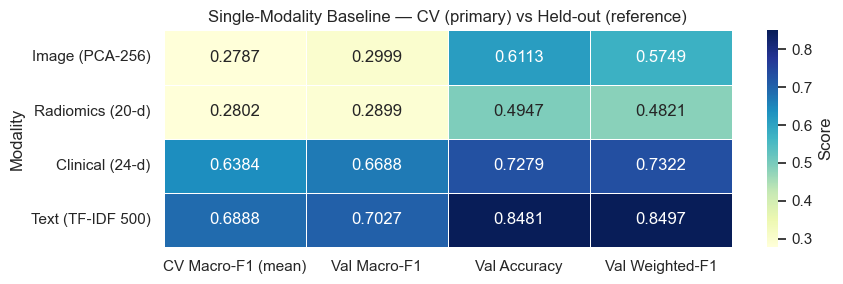

In [ ]:
# ── 2.1.1  Summary comparison table (CV + held-out) ──
summary_rows = []
for mod, d in single_detail.items():
    summary_rows.append({
        'Modality': mod,
        'CV Macro-F1 (mean)': d['cv_mean'],
        'CV Macro-F1 (std)': d['cv_std'],
        'Val Macro-F1': d['macro_f1'],
        'Val Accuracy': d['accuracy'],
        'Val Weighted-F1': d['weighted_f1'],
    })
df_summary = pd.DataFrame(summary_rows).set_index('Modality')
print('Single-Modality Performance Summary')
print('  CV = Stratified 5-Fold on train.json (primary)')
print('  Val = Held-out val.json (reference)')
print('=' * 70)
print(df_summary.to_string(float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(9, 3))
df_plot = df_summary[['CV Macro-F1 (mean)', 'Val Macro-F1', 'Val Accuracy', 'Val Weighted-F1']]
sns.heatmap(df_plot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('Single-Modality Baseline — CV (primary) vs Held-out (reference)')
plt.tight_layout()
plt.show()

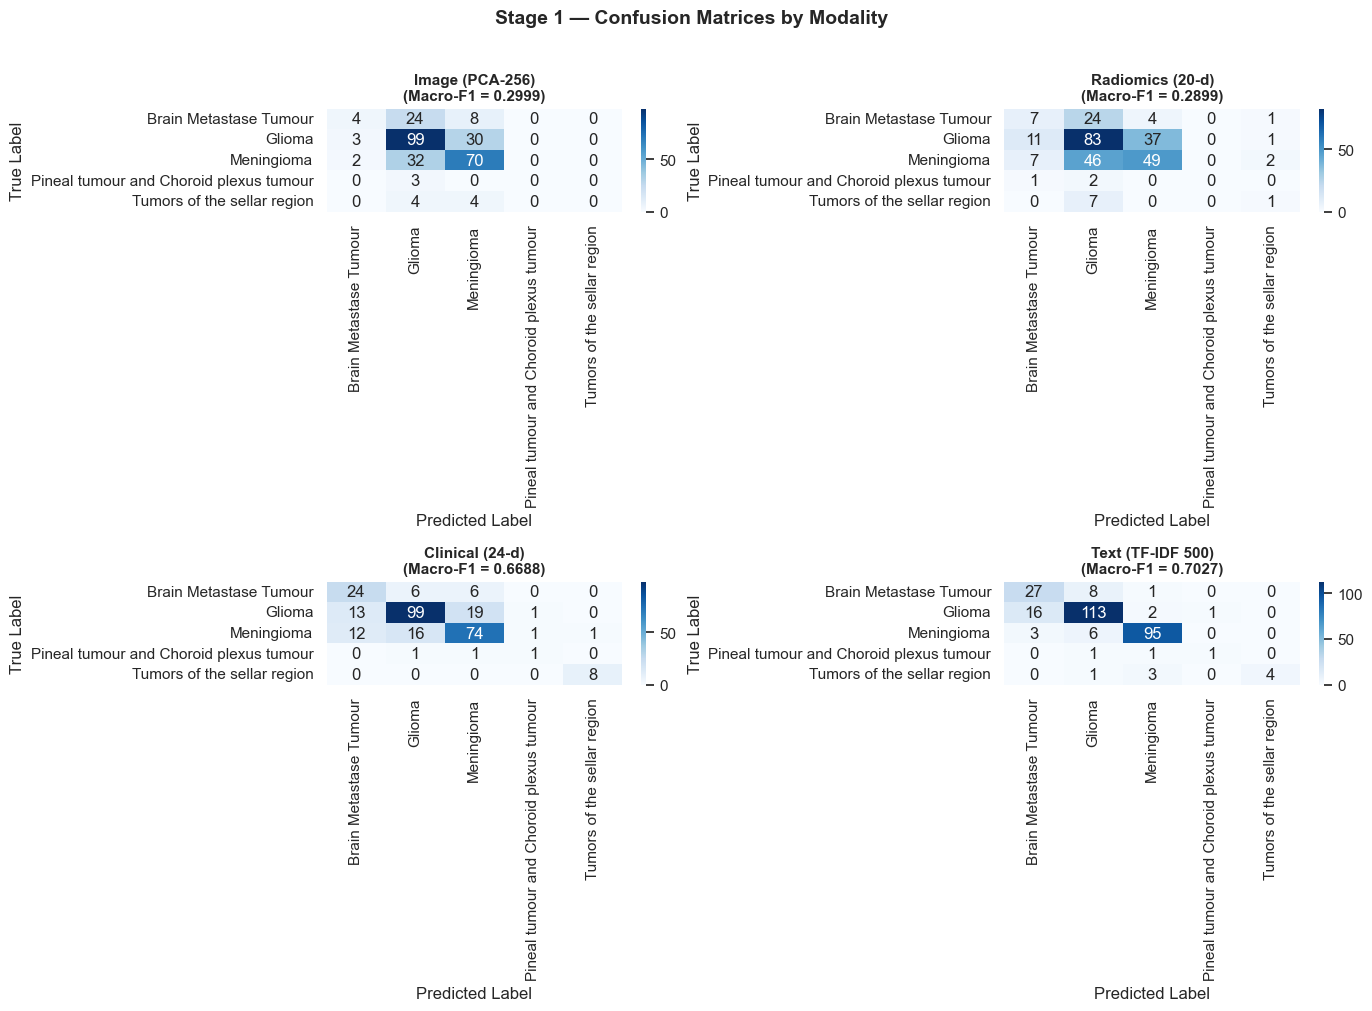

In [ ]:
# ── 2.1.2  Confusion matrices (2×2 grid) ──
class_names = label_encoder.classes_
modalities = list(single_detail.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for idx, mod in enumerate(modalities):
    cm = confusion_matrix(y_val, single_detail[mod]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx])
    axes[idx].set_title(f'{mod}\n(Macro-F1 = {single_detail[mod]["macro_f1"]:.4f})',
                        fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.suptitle('Stage 1 — Confusion Matrices by Modality', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

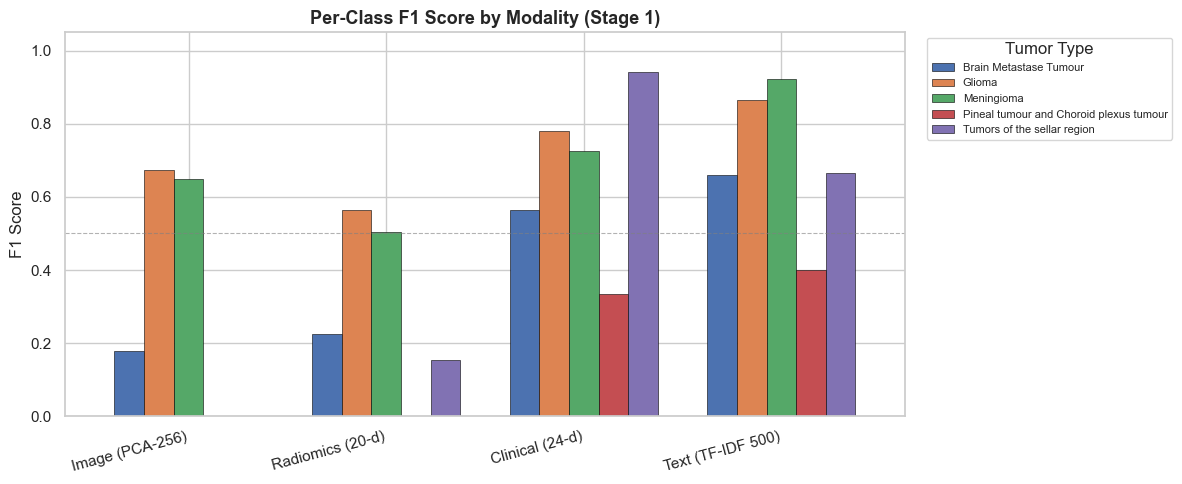


Per-class F1 detail:
                   Brain Metastase Tumour  Glioma  Meningioma  Pineal tumour and Choroid plexus tumour  Tumors of the sellar region
Image (PCA-256)                    0.1778  0.6735      0.6481                                   0.0000                       0.0000
Radiomics (20-d)                   0.2258  0.5646      0.5052                                   0.0000                       0.1538
Clinical (24-d)                    0.5647  0.7795      0.7255                                   0.3333                       0.9412
Text (TF-IDF 500)                  0.6585  0.8659      0.9223                                   0.4000                       0.6667


In [ ]:
# ── 2.1.3  Per-class F1 grouped bar chart ──
from sklearn.metrics import f1_score as _f1

per_class_data = {}
for mod, d in single_detail.items():
    per_class_f1 = _f1(y_val, d['y_pred'], average=None, labels=range(len(class_names)))
    per_class_data[mod] = per_class_f1

df_perclass = pd.DataFrame(per_class_data, index=class_names).T

fig, ax = plt.subplots(figsize=(12, 5))
df_perclass.plot(kind='bar', ax=ax, width=0.75, edgecolor='black', linewidth=0.4)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score by Modality (Stage 1)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(title='Tumor Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

print('\nPer-class F1 detail:')
print(df_perclass.round(4).to_string())

---
# 3. Stage 2 — Multimodal Fusion

We compare **early fusion** (concatenated features → single model) and **late fusion** (combine single-modality predictions).

## 3.1 Early Fusion — Model Comparison

Using the 800-d concatenated feature set, we train models of increasing flexibility.

In [ ]:
def evaluate_model(model, X_val, y_val, name='Model', run_cv=True):
    """
    Two-step evaluation per Lecture 4.1:
      1. Stratified 5-fold CV on training set  →  primary (model selection)
         Uses sklearn.base.clone so the fitted model is preserved.
      2. Evaluate fitted model on held-out val  →  reference
    """
    cv_scores = None
    if run_cv:
        cv_pipe = make_pipeline(StandardScaler(), clone(model))
        cv_scores = cross_val_score(cv_pipe, X_train_all, y_train,
                                    cv=skf, scoring='f1_macro', n_jobs=-1)

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1m = f1_score(y_val, y_pred, average='macro')
    f1w = f1_score(y_val, y_pred, average='weighted')

    y_proba = None
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_val)

    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    if cv_scores is not None:
        print(f'  [CV]  Macro-F1 = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  '
              f'(folds: {", ".join(f"{s:.3f}" for s in cv_scores)})')
    print(f'  [Val] Macro-F1 = {f1m:.4f}  |  Accuracy = {acc:.4f}  |  '
          f'Weighted-F1 = {f1w:.4f}')
    print(f'\nClassification Report (held-out val):')
    print(classification_report(y_val, y_pred,
                                target_names=label_encoder.classes_, digits=4))

    result = {'macro_f1': f1m, 'accuracy': acc, 'weighted_f1': f1w,
              'y_pred': y_pred, 'y_proba': y_proba}
    if cv_scores is not None:
        result['cv_scores'] = cv_scores
        result['cv_mean'] = cv_scores.mean()
        result['cv_std'] = cv_scores.std()
    return result

early_results = {}
early_detail = {}

In [ ]:
# 3.1.1 Logistic Regression (L2) — linear baseline
lr = LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced',
                        solver='lbfgs', random_state=SEED)
lr.fit(X_train_scaled, y_train)
early_detail['LR (L2)'] = evaluate_model(lr, X_val_scaled, y_val, 'Logistic Regression (L2)')
early_results['LR (L2)'] = early_detail['LR (L2)']['macro_f1']


  Logistic Regression (L2)
  [CV]  Macro-F1 = 0.6941 ± 0.0523  (folds: 0.743, 0.662, 0.746, 0.609, 0.711)
  [Val] Macro-F1 = 0.7039  |  Accuracy = 0.7915  |  Weighted-F1 = 0.7981

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.4898    0.6667    0.5647        36
                                 Glioma     0.8430    0.7727    0.8063       132
                             Meningioma     0.8835    0.8750    0.8792       104
Pineal tumour and Choroid plexus tumour     0.4000    0.6667    0.5000         3
            Tumors of the sellar region     1.0000    0.6250    0.7692         8

                               accuracy                         0.7915       283
                              macro avg     0.7233    0.7212    0.7039       283
                           weighted avg     0.8127    0.7915    0.7981       283



In [ ]:
# 3.1.2 Random Forest — bagging ensemble
rf = RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=2,
                            class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
early_detail['RF'] = evaluate_model(rf, X_val_scaled, y_val, 'Random Forest')
early_results['RF'] = early_detail['RF']['macro_f1']


  Random Forest
  [CV]  Macro-F1 = 0.4852 ± 0.0431  (folds: 0.474, 0.566, 0.480, 0.470, 0.436)
  [Val] Macro-F1 = 0.4754  |  Accuracy = 0.7173  |  Weighted-F1 = 0.6849

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.7143    0.1389    0.2326        36
                                 Glioma     0.6685    0.9015    0.7677       132
                             Meningioma     0.8065    0.7212    0.7614       104
Pineal tumour and Choroid plexus tumour     0.0000    0.0000    0.0000         3
            Tumors of the sellar region     0.8000    0.5000    0.6154         8

                               accuracy                         0.7173       283
                              macro avg     0.5979    0.4523    0.4754       283
                           weighted avg     0.7217    0.7173    0.6849       283



In [ ]:
# 3.1.3 SVM (RBF kernel)
svm = SVC(C=10, kernel='rbf', gamma='scale', class_weight='balanced',
          random_state=SEED, probability=True)
svm.fit(X_train_scaled, y_train)
early_detail['SVM-RBF'] = evaluate_model(svm, X_val_scaled, y_val, 'SVM (RBF)')
early_results['SVM-RBF'] = early_detail['SVM-RBF']['macro_f1']


  SVM (RBF)
  [CV]  Macro-F1 = 0.7029 ± 0.0367  (folds: 0.734, 0.710, 0.744, 0.642, 0.684)
  [Val] Macro-F1 = 0.7834  |  Accuracy = 0.8587  |  Weighted-F1 = 0.8581

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.6316    0.6667    0.6486        36
                                 Glioma     0.8540    0.8864    0.8699       132
                             Meningioma     0.9412    0.9231    0.9320       104
Pineal tumour and Choroid plexus tumour     1.0000    0.6667    0.8000         3
            Tumors of the sellar region     1.0000    0.5000    0.6667         8

                               accuracy                         0.8587       283
                              macro avg     0.8854    0.7286    0.7834       283
                           weighted avg     0.8634    0.8587    0.8581       283



In [ ]:
# 3.1.4 XGBoost — boosting ensemble
xgb_model = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, objective='multi:softprob', num_class=5,
    eval_metric='mlogloss', random_state=SEED, use_label_encoder=False)
xgb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)
early_detail['XGB'] = evaluate_model(xgb_model, X_val_scaled, y_val, 'XGBoost')
early_results['XGB'] = early_detail['XGB']['macro_f1']


  XGBoost
  [CV]  Macro-F1 = 0.6211 ± 0.0496  (folds: 0.702, 0.638, 0.627, 0.567, 0.571)
  [Val] Macro-F1 = 0.7288  |  Accuracy = 0.8233  |  Weighted-F1 = 0.8171

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.6296    0.4722    0.5397        36
                                 Glioma     0.8143    0.8636    0.8382       132
                             Meningioma     0.8785    0.9038    0.8910       104
Pineal tumour and Choroid plexus tumour     1.0000    0.3333    0.5000         3
            Tumors of the sellar region     0.8750    0.8750    0.8750         8

                               accuracy                         0.8233       283
                              macro avg     0.8395    0.6896    0.7288       283
                           weighted avg     0.8181    0.8233    0.8171       283



In [ ]:
# 3.1.5 LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, num_leaves=63,
    class_weight='balanced', random_state=SEED, verbose=-1)
lgb_model.fit(X_train_scaled, y_train)
early_detail['LGB'] = evaluate_model(lgb_model, X_val_scaled, y_val, 'LightGBM')
early_results['LGB'] = early_detail['LGB']['macro_f1']

/opt/anaconda3/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:13: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/opt/anaconda3/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:13: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/opt/anaconda3/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:13: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/opt/anaconda3/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:13: Fu


  LightGBM
  [CV]  Macro-F1 = 0.6280 ± 0.0298  (folds: 0.655, 0.672, 0.603, 0.604, 0.606)
  [Val] Macro-F1 = 0.6268  |  Accuracy = 0.8233  |  Weighted-F1 = 0.8134

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.6154    0.4444    0.5161        36
                                 Glioma     0.7945    0.8788    0.8345       132
                             Meningioma     0.9126    0.9038    0.9082       104
Pineal tumour and Choroid plexus tumour     0.0000    0.0000    0.0000         3
            Tumors of the sellar region     0.8750    0.8750    0.8750         8

                               accuracy                         0.8233       283
                              macro avg     0.6395    0.6204    0.6268       283
                           weighted avg     0.8090    0.8233    0.8134       283



In [ ]:
# 3.1.6 MLP Neural Network
mlp = MLPClassifier(hidden_layer_sizes=(512, 256, 128), activation='relu',
    max_iter=500, early_stopping=True, validation_fraction=0.1,
    batch_size=64, learning_rate='adaptive', learning_rate_init=0.001, random_state=SEED)
mlp.fit(X_train_scaled, y_train)
early_detail['MLP'] = evaluate_model(mlp, X_val_scaled, y_val, 'MLP')
early_results['MLP'] = early_detail['MLP']['macro_f1']


  MLP
  [CV]  Macro-F1 = 0.7255 ± 0.0251  (folds: 0.758, 0.723, 0.750, 0.696, 0.700)
  [Val] Macro-F1 = 0.7051  |  Accuracy = 0.8375  |  Weighted-F1 = 0.8366

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.6098    0.6944    0.6494        36
                                 Glioma     0.8550    0.8485    0.8517       132
                             Meningioma     0.9048    0.9135    0.9091       104
Pineal tumour and Choroid plexus tumour     1.0000    0.3333    0.5000         3
            Tumors of the sellar region     0.8000    0.5000    0.6154         8

                               accuracy                         0.8375       283
                              macro avg     0.8339    0.6579    0.7051       283
                           weighted avg     0.8421    0.8375    0.8366       283



## 3.1.7 PyTorch Multi-Branch Multimodal MLP

A modality-specific deep neural network that encodes image PCA, radiomics, clinical, and TF-IDF text features in separate branches before fusion.

In [ ]:
class MultiModalTensorDataset(Dataset):
    def __init__(self, modalities, labels=None):
        self.modalities = {
            name: torch.tensor(values, dtype=torch.float32)
            for name, values in modalities.items()
        }
        self.labels = None if labels is None else torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        first_key = next(iter(self.modalities))
        return self.modalities[first_key].shape[0]

    def __getitem__(self, idx):
        item = {name: values[idx] for name, values in self.modalities.items()}
        if self.labels is not None:
            return item, self.labels[idx]
        return item


def build_mlp_block(input_dim, hidden_dims, dropout):
    layers = []
    prev_dim = input_dim
    for hidden_dim in hidden_dims:
        layers.extend([
            nn.Linear(prev_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        ])
        prev_dim = hidden_dim
    return nn.Sequential(*layers)


class MultiBranchMultimodalMLP(nn.Module):
    def __init__(self, input_dims, n_classes, dropout=0.25):
        super().__init__()
        self.img_branch = build_mlp_block(input_dims['img'], [128, 64], dropout)
        self.rad_branch = build_mlp_block(input_dims['rad'], [32, 16], dropout)
        self.clin_branch = build_mlp_block(input_dims['clin'], [32, 16], dropout)
        self.text_branch = build_mlp_block(input_dims['text'], [256, 64], dropout)

        fusion_dim = 64 + 16 + 16 + 64
        self.fusion_head = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, batch):
        img_feat = self.img_branch(batch['img'])
        rad_feat = self.rad_branch(batch['rad'])
        clin_feat = self.clin_branch(batch['clin'])
        text_feat = self.text_branch(batch['text'])
        fused = torch.cat([img_feat, rad_feat, clin_feat, text_feat], dim=1)
        return self.fusion_head(fused)


def get_torch_device():
    if torch.backends.mps.is_available():
        return torch.device('mps')
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


def set_torch_seed(seed=SEED):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def scale_modalities(train_modalities, val_modalities):
    scalers = {}
    train_scaled = {}
    val_scaled = {}
    for name in train_modalities:
        scaler = StandardScaler()
        train_scaled[name] = scaler.fit_transform(train_modalities[name]).astype(np.float32)
        val_scaled[name] = scaler.transform(val_modalities[name]).astype(np.float32)
        scalers[name] = scaler
    return train_scaled, val_scaled, scalers


def make_class_weight_tensor(y, n_classes, device):
    classes = np.arange(n_classes)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
    return torch.tensor(weights, dtype=torch.float32, device=device)


def predict_multimodal_mlp(model, modalities, batch_size=128, device=None):
    if device is None:
        device = get_torch_device()

    dataset = MultiModalTensorDataset(modalities)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    model.eval()
    probs = []
    preds = []
    with torch.inference_mode():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(batch)
            batch_probs = torch.softmax(logits, dim=1)
            probs.append(batch_probs.cpu().numpy())
            preds.append(batch_probs.argmax(dim=1).cpu().numpy())

    y_proba = np.vstack(probs)
    y_pred = np.concatenate(preds)
    return y_pred, y_proba


def compute_multimodal_loss(model, modalities, labels, criterion, batch_size=128, device=None):
    if device is None:
        device = get_torch_device()

    dataset = MultiModalTensorDataset(modalities, labels)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    model.eval()
    total_loss = 0.0
    with torch.inference_mode():
        for batch, y_batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            y_batch = y_batch.to(device)
            logits = model(batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * y_batch.size(0)
    return total_loss / len(dataset)


def fit_multimodal_mlp(
    train_modalities,
    y_train,
    val_modalities,
    y_val,
    epochs=40,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    patience=8,
    dropout=0.25,
    device=None,
    verbose=True,
):
    set_torch_seed(SEED)
    if device is None:
        device = get_torch_device()

    train_scaled, val_scaled, scalers = scale_modalities(train_modalities, val_modalities)
    input_dims = {name: values.shape[1] for name, values in train_scaled.items()}
    n_classes = len(label_encoder.classes_)

    train_dataset = MultiModalTensorDataset(train_scaled, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

    model = MultiBranchMultimodalMLP(input_dims, n_classes=n_classes, dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss(weight=make_class_weight_tensor(y_train, n_classes, device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = []
    best_state = None
    best_val_f1 = -np.inf
    best_val_loss = np.inf
    best_epoch = 0
    wait = 0

    val_features = {name: values for name, values in val_scaled.items()}
    y_val_np = np.asarray(y_val)

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for batch, labels in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(batch)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * labels.size(0)

        train_loss = running_loss / len(train_dataset)
        y_val_pred, y_val_proba = predict_multimodal_mlp(model, val_features, batch_size=batch_size, device=device)
        val_loss = compute_multimodal_loss(
            model,
            val_features,
            y_val_np,
            criterion,
            batch_size=batch_size,
            device=device,
        )
        val_macro_f1 = f1_score(y_val_np, y_val_pred, average='macro')
        val_weighted_f1 = f1_score(y_val_np, y_val_pred, average='weighted')

        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_macro_f1': val_macro_f1,
            'val_weighted_f1': val_weighted_f1,
        })

        improved = (
            val_macro_f1 > best_val_f1 + 1e-6 or
            (abs(val_macro_f1 - best_val_f1) <= 1e-6 and val_loss < best_val_loss)
        )
        if improved:
            best_val_f1 = val_macro_f1
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if verbose and (epoch == 1 or epoch % 5 == 0 or epoch == epochs):
            print(
                f"    Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f}"
            )

        if wait >= patience:
            if verbose:
                print(f"    Early stopping at epoch {epoch} (best epoch = {best_epoch})")
            break

    model.load_state_dict(best_state)
    y_pred, y_proba = predict_multimodal_mlp(model, val_features, batch_size=batch_size, device=device)

    return {
        'model': model,
        'scalers': scalers,
        'history': history,
        'device': str(device),
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_val_np, y_pred),
        'macro_f1': f1_score(y_val_np, y_pred, average='macro'),
        'weighted_f1': f1_score(y_val_np, y_pred, average='weighted'),
        'best_epoch': best_epoch,
    }


def cross_validate_multimodal_mlp(
    modalities,
    y,
    epochs=40,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    patience=8,
    dropout=0.25,
    device=None,
):
    scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(modalities['img'], y), start=1):
        fold_train = {name: values[tr_idx] for name, values in modalities.items()}
        fold_val = {name: values[va_idx] for name, values in modalities.items()}
        fold_result = fit_multimodal_mlp(
            fold_train,
            y[tr_idx],
            fold_val,
            y[va_idx],
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            weight_decay=weight_decay,
            patience=patience,
            dropout=dropout,
            device=device,
            verbose=False,
        )
        scores.append(fold_result['macro_f1'])
        print(f"    Fold {fold_idx}: Macro-F1 = {fold_result['macro_f1']:.4f}")
    return np.array(scores)


def evaluate_multimodal_mlp(
    train_modalities,
    val_modalities,
    y_train,
    y_val,
    name='PyTorch Multi-Branch MLP',
    run_cv=True,
    epochs=40,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    patience=8,
    dropout=0.25,
    device=None,
):
    if device is None:
        device = get_torch_device()

    cv_scores = None
    if run_cv:
        print('    Running 5-fold CV for Multi-Branch MLP...')
        cv_scores = cross_validate_multimodal_mlp(
            train_modalities,
            y_train,
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            weight_decay=weight_decay,
            patience=patience,
            dropout=dropout,
            device=device,
        )

    print(f'    Training final {name} on full training split...')
    result = fit_multimodal_mlp(
        train_modalities,
        y_train,
        val_modalities,
        y_val,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        patience=patience,
        dropout=dropout,
        device=device,
        verbose=True,
    )

    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    if cv_scores is not None:
        print(f'  [CV]  Macro-F1 = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  '
              f'(folds: {", ".join(f"{s:.3f}" for s in cv_scores)})')
    print(f"  [Val] Macro-F1 = {result['macro_f1']:.4f}  |  Accuracy = {result['accuracy']:.4f}  |  "
          f"Weighted-F1 = {result['weighted_f1']:.4f}")
    print(f"  [Info] Device = {result['device']} | Best epoch = {result['best_epoch']}")
    print(f'\nClassification Report (held-out val):')
    print(classification_report(y_val, result['y_pred'], target_names=label_encoder.classes_, digits=4))

    if cv_scores is not None:
        result['cv_scores'] = cv_scores
        result['cv_mean'] = cv_scores.mean()
        result['cv_std'] = cv_scores.std()
    return result


train_modalities = {
    'img': X_img_train_pca,
    'rad': X_rad_train,
    'clin': X_clin_train,
    'text': X_text_train,
}
val_modalities = {
    'img': X_img_val_pca,
    'rad': X_rad_val,
    'clin': X_clin_val,
    'text': X_text_val,
}

mm_mlp_name = 'PyTorch Multi-Branch MLP'
early_detail[mm_mlp_name] = evaluate_multimodal_mlp(
    train_modalities,
    val_modalities,
    y_train,
    y_val,
    name=mm_mlp_name,
    run_cv=True,
    epochs=35,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    patience=7,
    dropout=0.25,
)
early_results[mm_mlp_name] = early_detail[mm_mlp_name]['macro_f1']

    Running 5-fold CV for Multi-Branch MLP...
    Fold 1: Macro-F1 = 0.7770
    Fold 2: Macro-F1 = 0.7165
    Fold 3: Macro-F1 = 0.7829
    Fold 4: Macro-F1 = 0.7143
    Fold 5: Macro-F1 = 0.7176
    Training final PyTorch Multi-Branch MLP on full training split...
    Epoch 01 | train_loss=1.5529 | val_loss=1.4515 | val_macro_f1=0.4491
    Epoch 05 | train_loss=0.3762 | val_loss=0.6020 | val_macro_f1=0.6563
    Epoch 10 | train_loss=0.1312 | val_loss=0.7721 | val_macro_f1=0.6814
    Epoch 15 | train_loss=0.0976 | val_loss=0.8647 | val_macro_f1=0.6773
    Epoch 20 | train_loss=0.0980 | val_loss=1.1068 | val_macro_f1=0.6656
    Epoch 25 | train_loss=0.0524 | val_loss=0.9806 | val_macro_f1=0.7069
    Early stopping at epoch 25 (best epoch = 18)

  PyTorch Multi-Branch MLP
  [CV]  Macro-F1 = 0.7417 ± 0.0313  (folds: 0.777, 0.716, 0.783, 0.714, 0.718)
  [Val] Macro-F1 = 0.7186  |  Accuracy = 0.8233  |  Weighted-F1 = 0.8289
  [Info] Device = mps | Best epoch = 18

Classification Report (hel

## 3.2 Late Fusion — Voting & Stacking

Combine predictions from individually strong models. This preserves modality-specific structure.

In [ ]:
late_results = {}
late_detail = {}

# 3.2.1 Soft Voting (early-fusion models combined by probability averaging)
# Note: run_cv=False for ensemble wrappers — CV is done on base learners above
voting_clf = VotingClassifier(estimators=[
    ('svm', SVC(C=10, kernel='rbf', gamma='scale', class_weight='balanced', random_state=SEED, probability=True)),
    ('xgb', xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=SEED, use_label_encoder=False, eval_metric='mlogloss')),
    ('lgb', lgb.LGBMClassifier(n_estimators=500, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, num_leaves=63, class_weight='balanced', random_state=SEED, verbose=-1)),
    ('lr', LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced', random_state=SEED)),
], voting='soft')
voting_clf.fit(X_train_scaled, y_train)
late_detail['Soft Voting'] = evaluate_model(voting_clf, X_val_scaled, y_val,
                                            'Late Fusion: Soft Voting', run_cv=False)
late_results['Soft Voting'] = late_detail['Soft Voting']['macro_f1']


  Late Fusion: Soft Voting
  [Val] Macro-F1 = 0.7816  |  Accuracy = 0.8445  |  Weighted-F1 = 0.8442

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.6000    0.5833    0.5915        36
                                 Glioma     0.8507    0.8636    0.8571       132
                             Meningioma     0.9223    0.9135    0.9179       104
Pineal tumour and Choroid plexus tumour     0.6667    0.6667    0.6667         3
            Tumors of the sellar region     0.8750    0.8750    0.8750         8

                               accuracy                         0.8445       283
                              macro avg     0.7829    0.7804    0.7816       283
                           weighted avg     0.8439    0.8445    0.8442       283



In [ ]:
# 3.2.2 Stacking (meta-learner: LR on base model outputs, internal 5-fold CV)
# StackingClassifier already uses cv=5 internally for generating meta-features
stacking_clf = StackingClassifier(estimators=[
    ('svm', SVC(C=10, kernel='rbf', gamma='scale', class_weight='balanced', random_state=SEED, probability=True)),
    ('xgb', xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=SEED, use_label_encoder=False, eval_metric='mlogloss')),
    ('lgb', lgb.LGBMClassifier(n_estimators=500, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, num_leaves=63, class_weight='balanced', random_state=SEED, verbose=-1)),
    ('rf', RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=2, class_weight='balanced', random_state=SEED)),
], final_estimator=LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED), cv=5)
stacking_clf.fit(X_train_scaled, y_train)
late_detail['Stacking'] = evaluate_model(stacking_clf, X_val_scaled, y_val,
                                         'Late Fusion: Stacking', run_cv=False)
late_results['Stacking'] = late_detail['Stacking']['macro_f1']


  Late Fusion: Stacking
  [Val] Macro-F1 = 0.7295  |  Accuracy = 0.8339  |  Weighted-F1 = 0.8445

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.5385    0.7778    0.6364        36
                                 Glioma     0.9123    0.7879    0.8455       132
                             Meningioma     0.9406    0.9135    0.9268       104
Pineal tumour and Choroid plexus tumour     0.2500    0.6667    0.3636         3
            Tumors of the sellar region     0.8750    0.8750    0.8750         8

                               accuracy                         0.8339       283
                              macro avg     0.7033    0.8042    0.7295       283
                           weighted avg     0.8671    0.8339    0.8445       283



## 3.3 Stage 2 — Comprehensive Result Comparison (Tutorial 7 Style)

Following Tutorial 7's reporting pattern, we produce:
1. **Summary table** with Accuracy, Macro-F1, Weighted-F1, and macro-averaged AUROC
2. **Confusion matrix grid** for all fusion models
3. **Multiclass ROC curves** (One-vs-Rest, macro-averaged)
4. **Precision–Recall curves** (One-vs-Rest)

FULL MODEL COMPARISON
  CV = 5-Fold on train.json (primary)  |  Val = held-out val.json (reference)
                                         CV Macro-F1  Val Macro-F1  Val Accuracy  Val Weighted-F1  AUROC (macro)
Model                                                                                                           
SVM-RBF (Optimized 4.1: L1 top-128)  0.7344 ± 0.0301      0.785295      0.833922         0.833513       0.953522
SVM-RBF                              0.7029 ± 0.0367      0.783449      0.858657         0.858099       0.963284
Soft Voting                                        —      0.781647      0.844523         0.844161       0.968512
XGB                                  0.6211 ± 0.0496      0.728783      0.823322         0.817099       0.962703
PyTorch Multi-Branch MLP             0.7417 ± 0.0313      0.718579      0.823322         0.828869       0.927251
MLP                                  0.7255 ± 0.0251      0.705107      0.837456         0.836647       0.916

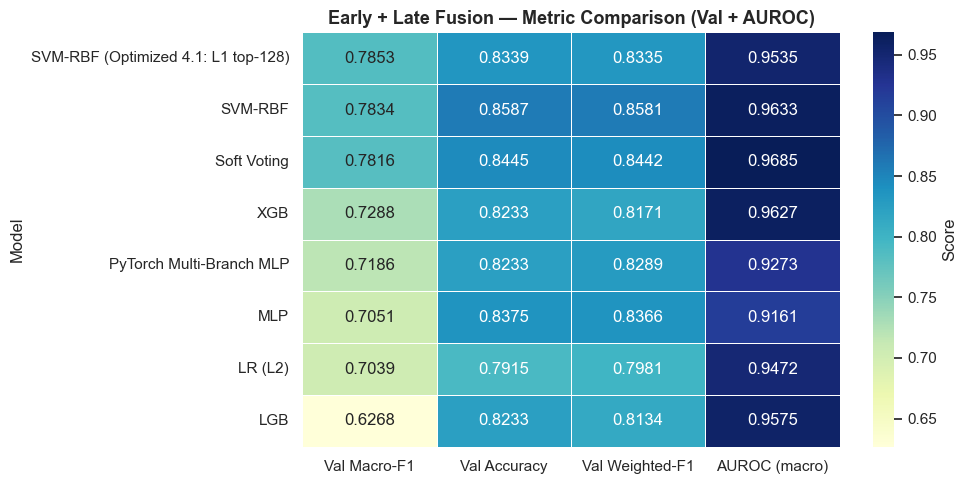

In [ ]:
# ── 3.3.1  Comprehensive summary table (CV + Val + AUROC) ──
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

all_detail = {**early_detail, **late_detail}
n_classes = len(label_encoder.classes_)
y_val_bin = label_binarize(y_val, classes=range(n_classes))

summary_rows = []
for name, d in all_detail.items():
    row = {'Model': name,
           'CV Macro-F1': f"{d.get('cv_mean', float('nan')):.4f} ± {d.get('cv_std', float('nan')):.4f}"
                          if 'cv_mean' in d else '—',
           'Val Macro-F1': d['macro_f1'],
           'Val Accuracy': d['accuracy'],
           'Val Weighted-F1': d['weighted_f1']}
    if d['y_proba'] is not None:
        row['AUROC (macro)'] = roc_auc_score(y_val_bin, d['y_proba'],
                                              average='macro', multi_class='ovr')
    else:
        row['AUROC (macro)'] = float('nan')
    summary_rows.append(row)

df_fusion = pd.DataFrame(summary_rows).set_index('Model')
df_fusion_numeric = df_fusion.drop(columns=['CV Macro-F1']).sort_values('Val Macro-F1', ascending=False)

print('FULL MODEL COMPARISON')
print('  CV = 5-Fold on train.json (primary)  |  Val = held-out val.json (reference)')
print('=' * 80)
print(df_fusion.sort_values('Val Macro-F1', ascending=False).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_fusion_numeric, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('Early + Late Fusion — Metric Comparison (Val + AUROC)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

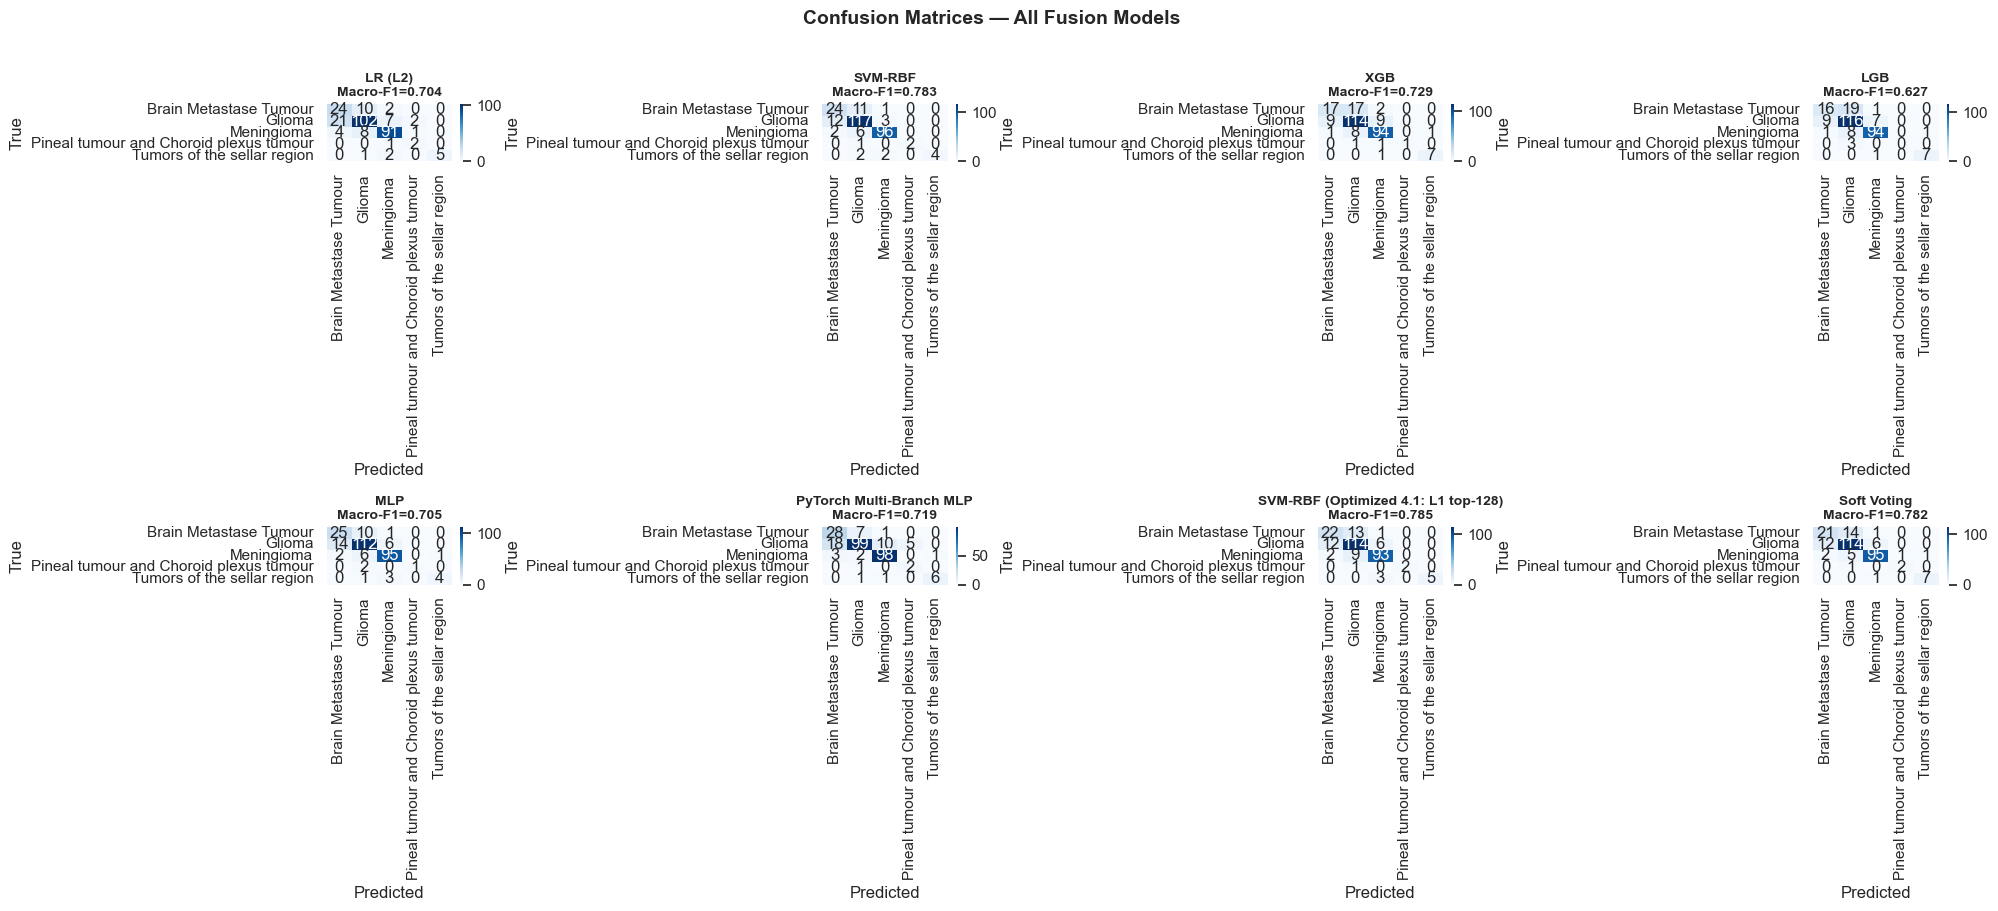

In [ ]:
# ── 3.3.2  Confusion matrix grid for all fusion models ──
model_names = list(all_detail.keys())
n_models = len(model_names)
ncols = 4
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = axes.ravel() if n_models > 1 else [axes]

for idx, name in enumerate(model_names):
    cm = confusion_matrix(y_val, all_detail[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[idx])
    axes[idx].set_title(f'{name}\nMacro-F1={all_detail[name]["macro_f1"]:.3f}',
                        fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('True')
    axes[idx].set_xlabel('Predicted')

for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices — All Fusion Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

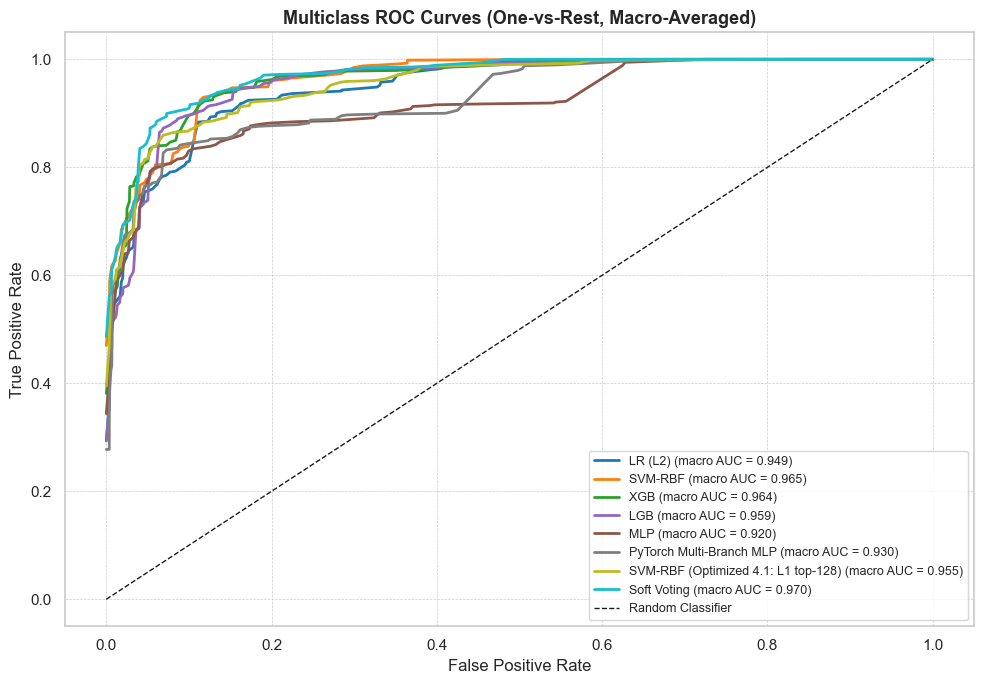

In [ ]:
# ── 3.3.3  Multiclass ROC curves (One-vs-Rest, macro-averaged) ──
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_detail)))

for (name, d), color in zip(all_detail.items(), colors):
    if d['y_proba'] is None:
        continue
    fpr_macro, tpr_macro = dict(), dict()
    for i in range(n_classes):
        fpr_macro[i], tpr_macro[i], _ = roc_curve(y_val_bin[:, i], d['y_proba'][:, i])
    all_fpr = np.unique(np.concatenate([fpr_macro[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_macro[i], tpr_macro[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, color=color, lw=2,
            label=f'{name} (macro AUC = {macro_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Multiclass ROC Curves (One-vs-Rest, Macro-Averaged)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(visible=True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

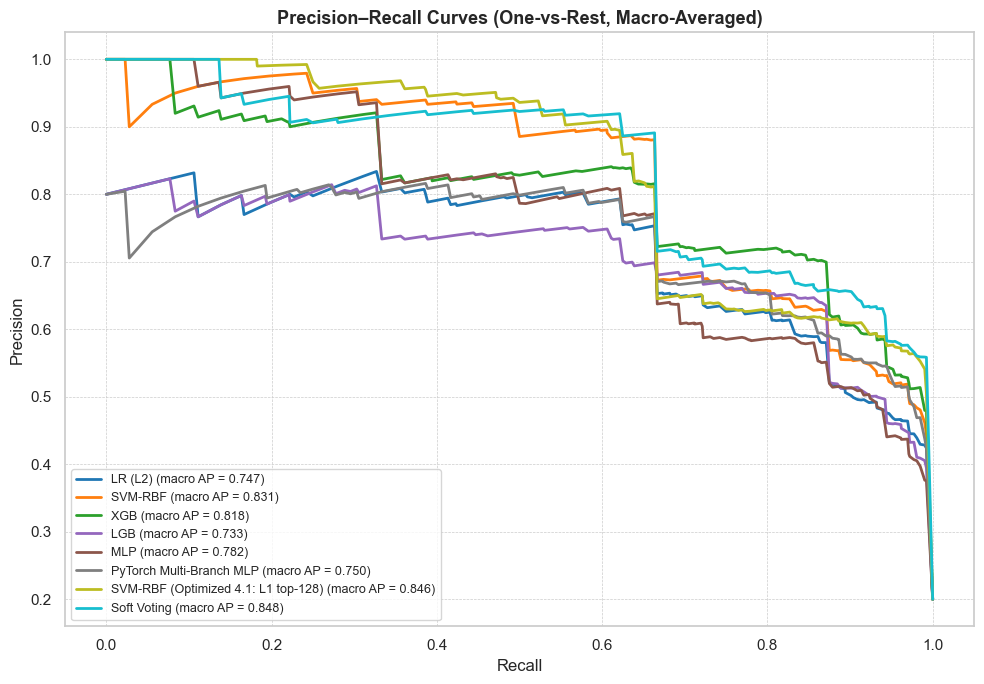

In [ ]:
# ── 3.3.4  Precision–Recall curves (One-vs-Rest, macro-averaged) ──
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(10, 7))

for (name, d), color in zip(all_detail.items(), colors):
    if d['y_proba'] is None:
        continue
    prec_avg, rec_avg = dict(), dict()
    for i in range(n_classes):
        prec_avg[i], rec_avg[i], _ = precision_recall_curve(y_val_bin[:, i], d['y_proba'][:, i])
    macro_ap = average_precision_score(y_val_bin, d['y_proba'], average='macro')
    all_recall = np.unique(np.concatenate([rec_avg[i] for i in range(n_classes)]))
    mean_prec = np.zeros_like(all_recall)
    for i in range(n_classes):
        mean_prec += np.interp(all_recall, rec_avg[i][::-1], prec_avg[i][::-1])
    mean_prec /= n_classes
    ax.plot(all_recall, mean_prec, color=color, lw=2,
            label=f'{name} (macro AP = {macro_ap:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision–Recall Curves (One-vs-Rest, Macro-Averaged)', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.grid(visible=True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

---
# 4. Stage 3 — Optimization

This section implements the planned feature-selection experiments for the multimodal early-fusion pipeline.

### 4.1 Feature Selection
We evaluate three complementary feature-selection strategies on the fused feature space:
- `LASSO (L1)` via sparse multinomial logistic regression coefficients
- `Random Forest` importance ranking
- `Mutual Information` ranking

We also test two structural feature-reduction steps:
- remove radiomics pairs with `|r| > 0.95`
- tune image PCA dimensionality over `128 / 256 / 512`

All comparisons report both `Stratified 5-fold CV Macro-F1` and held-out validation `Macro-F1`.

### 4.2 Class Imbalance Experiments
- (a) `class_weight='balanced'` (current default)
- (b) Random oversampling of minority classes (train only)
- (c) SMOTE in PCA-reduced feature space (train only)
- Report per-class F1 and macro-F1 for each strategy

### 4.3 Hyperparameter Tuning
- Stratified 5-fold CV on train set for top-2 models
- Grid search over key parameters (e.g., LGB n_estimators, max_depth, learning_rate)

In [ ]:
# ── 4.1.1  Helper utilities for feature-selection experiments ──
rad_feat_names = [f'{mod}_{feat}' for mod in MODALITIES for feat in RADIOMICS_FEAT_COLS]
clin_feat_names = [f'clin_{c}' for c in clinical_feat_cols]
text_feat_names = [f'tfidf_{i}' for i in range(X_text_train.shape[1])]


def build_feature_selection_dataset(img_pca_components=256, rad_keep_cols=None):
    n_comp = min(img_pca_components, X_img_train.shape[0], X_img_train.shape[1])
    pca = PCA(n_components=n_comp, random_state=SEED)
    X_img_train_fs = pca.fit_transform(X_img_train)
    X_img_val_fs = pca.transform(X_img_val)
    img_feat_names = [f'img_pc{i}' for i in range(n_comp)]

    if rad_keep_cols is None:
        rad_keep_cols = rad_feat_names
    rad_keep_idx = [rad_feat_names.index(c) for c in rad_keep_cols]

    X_rad_train_fs = X_rad_train[:, rad_keep_idx]
    X_rad_val_fs = X_rad_val[:, rad_keep_idx]

    X_train_fs = np.hstack([X_img_train_fs, X_rad_train_fs, X_clin_train, X_text_train])
    X_val_fs = np.hstack([X_img_val_fs, X_rad_val_fs, X_clin_val, X_text_val])
    feat_names = img_feat_names + list(rad_keep_cols) + clin_feat_names + text_feat_names
    explained_var = pca.explained_variance_ratio_.sum()
    return X_train_fs, X_val_fs, feat_names, explained_var



def evaluate_feature_subset(X_train_sel, X_val_sel, y_train, y_val, name, run_cv=True):
    model = lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        class_weight='balanced',
        random_state=SEED,
        verbose=-1
    )

    scaler_fs = StandardScaler()
    X_train_sel_scaled = scaler_fs.fit_transform(X_train_sel)
    X_val_sel_scaled = scaler_fs.transform(X_val_sel)
    model.fit(X_train_sel_scaled, y_train)
    y_pred = model.predict(X_val_sel_scaled)

    result = {
        'name': name,
        'n_features': X_train_sel.shape[1],
        'val_macro_f1': f1_score(y_val, y_pred, average='macro')
    }

    if run_cv:
        cv_pipe = make_pipeline(StandardScaler(), clone(model))
        cv_scores = cross_val_score(
            cv_pipe,
            X_train_sel,
            y_train,
            cv=skf,
            scoring='f1_macro',
            n_jobs=-1
        )
        result['cv_mean'] = cv_scores.mean()
        result['cv_std'] = cv_scores.std()

    return result



def rank_features_l1(X_train_fs, y_train):
    scaler_l1 = StandardScaler()
    X_train_scaled_l1 = scaler_l1.fit_transform(X_train_fs)
    l1_selector = LogisticRegression(
        penalty='l1',
        solver='saga',
        C=0.2,
        max_iter=4000,
        class_weight='balanced',
        random_state=SEED
    )
    l1_selector.fit(X_train_scaled_l1, y_train)
    scores = np.abs(l1_selector.coef_).mean(axis=0)
    ranking = np.argsort(scores)[::-1]
    nonzero_idx = np.flatnonzero(scores > 1e-8)
    return scores, ranking, nonzero_idx



def rank_features_rf(X_train_fs, y_train):
    rf_selector = RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=SEED,
        n_jobs=-1
    )
    rf_selector.fit(X_train_fs, y_train)
    scores = rf_selector.feature_importances_
    ranking = np.argsort(scores)[::-1]
    return scores, ranking



def rank_features_mi(X_train_fs, y_train):
    scores = mutual_info_classif(X_train_fs, y_train, random_state=SEED)
    ranking = np.argsort(scores)[::-1]
    return scores, ranking

In [ ]:
# ── 4.1.2  Remove highly correlated radiomics features and compare L1 / RF / MI ──
rad_train_df = pd.DataFrame(X_rad_train, columns=rad_feat_names)
rad_corr_abs = rad_train_df.corr().abs()
upper = rad_corr_abs.where(np.triu(np.ones(rad_corr_abs.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .loc[lambda s: s > 0.95]
)
rad_drop_cols = [c for c in upper.columns if (upper[c] > 0.95).any()]
rad_keep_cols = [c for c in rad_feat_names if c not in rad_drop_cols]

print('Highly correlated radiomics pairs (|r| > 0.95):')
if len(high_corr_pairs) == 0:
    print('  None found.')
else:
    for (f1, f2), corr_val in high_corr_pairs.items():
        print(f'  {f1:<35s} vs {f2:<35s} | r = {corr_val:.3f}')

print(f'\nRadiomics features before filter: {len(rad_feat_names)}')
print(f'Radiomics features after filter:  {len(rad_keep_cols)}')
if rad_drop_cols:
    print('Dropped features:')
    for c in rad_drop_cols:
        print(f'  - {c}')

X_train_fs, X_val_fs, fs_feat_names, fs_explained_var = build_feature_selection_dataset(
    img_pca_components=256,
    rad_keep_cols=rad_keep_cols
)
print(f'\nFeature-selection dataset: {X_train_fs.shape[1]} features total')
print(f'Image PCA explained variance (256 comp): {fs_explained_var:.4f}')

fs_results = []
fs_results.append(evaluate_feature_subset(X_train_fs, X_val_fs, y_train, y_val, 'All features (de-correlated rad)'))

l1_scores, l1_ranking, l1_nonzero_idx = rank_features_l1(X_train_fs, y_train)
rf_scores, rf_ranking = rank_features_rf(X_train_fs, y_train)
mi_scores, mi_ranking = rank_features_mi(X_train_fs, y_train)

ranking_tables = {
    'L1': pd.Series(l1_scores, index=fs_feat_names).sort_values(ascending=False),
    'RF': pd.Series(rf_scores, index=fs_feat_names).sort_values(ascending=False),
    'MI': pd.Series(mi_scores, index=fs_feat_names).sort_values(ascending=False),
}

print(f'\nL1 non-zero features selected: {len(l1_nonzero_idx)}')
for method, table in ranking_tables.items():
    print(f'\nTop 10 features by {method}:')
    display(table.head(10).to_frame(name='score'))

k_grid = [64, 128, 256]
for k in k_grid:
    for method, ranking in [('L1', l1_ranking), ('RF', rf_ranking), ('MI', mi_ranking)]:
        selected_idx = ranking[:min(k, len(ranking))]
        fs_results.append(
            evaluate_feature_subset(
                X_train_fs[:, selected_idx],
                X_val_fs[:, selected_idx],
                y_train,
                y_val,
                f'{method} top-{len(selected_idx)}'
            )
        )

if len(l1_nonzero_idx) > 0:
    fs_results.append(
        evaluate_feature_subset(
            X_train_fs[:, l1_nonzero_idx],
            X_val_fs[:, l1_nonzero_idx],
            y_train,
            y_val,
            f'L1 non-zero ({len(l1_nonzero_idx)})'
        )
    )

fs_summary = pd.DataFrame(fs_results).sort_values(
    ['val_macro_f1', 'cv_mean'],
    ascending=False
).reset_index(drop=True)

print('\nFEATURE SELECTION SUMMARY (sorted by Val Macro-F1)')
display(fs_summary.style.format({
    'cv_mean': '{:.4f}',
    'cv_std': '{:.4f}',
    'val_macro_f1': '{:.4f}'
}))

best_fs_config = fs_summary.iloc[0].to_dict()
print(f"\nBest feature-selection config: {best_fs_config['name']} | "
      f"{int(best_fs_config['n_features'])} features | "
      f"Val Macro-F1 = {best_fs_config['val_macro_f1']:.4f}")

Highly correlated radiomics pairs (|r| > 0.95):
  ax_t1c_rad_firstorder_Entropy       vs ax_t1c_rad_glcm_JointEntropy        | r = 0.997
  ax_t2_rad_firstorder_Entropy        vs ax_t2_rad_glcm_JointEntropy         | r = 0.997
  ax_t2f_rad_firstorder_Entropy       vs ax_t2f_rad_glcm_JointEntropy        | r = 0.997
  ax_t1_rad_firstorder_Entropy        vs ax_t1_rad_glcm_JointEntropy         | r = 0.991

Radiomics features before filter: 20
Radiomics features after filter:  16
Dropped features:
  - ax_t1_rad_glcm_JointEntropy
  - ax_t1c_rad_glcm_JointEntropy
  - ax_t2_rad_glcm_JointEntropy
  - ax_t2f_rad_glcm_JointEntropy

Feature-selection dataset: 796 features total
Image PCA explained variance (256 comp): 0.9218


/opt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/anaconda3/lib/python3.12/site-pa


L1 non-zero features selected: 489

Top 10 features by L1:


,score
clin_loc_sella,0.368213
img_pc1,0.201046
tfidf_167,0.173525
clin_loc_ventricle,0.141193
tfidf_245,0.134226
tfidf_191,0.133588
clin_Age_filled,0.131240
img_pc115,0.126538
tfidf_351,0.119438
clin_Sex_enc,0.116195



Top 10 features by RF:


...

,score
tfidf_456,0.252014
tfidf_461,0.251431
tfidf_301,0.250678
tfidf_402,0.250577
tfidf_82,0.238429
tfidf_107,0.236042
tfidf_216,0.235963
tfidf_4,0.234314
tfidf_83,0.231632
tfidf_442,0.226165


/opt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]



FEATURE SELECTION SUMMARY (sorted by Val Macro-F1)


,name,n_features,val_macro_f1,cv_mean,cv_std
0,MI top-256,256,0.7613,0.6674,0.0602
1,MI top-128,128,0.7271,0.6741,0.0301
2,RF top-128,128,0.6656,0.6119,0.0576
3,MI top-64,64,0.6442,0.6331,0.0416
4,L1 top-128,128,0.6250,0.6692,0.0568
5,L1 non-zero (489),489,0.6246,0.6269,0.0422
6,All features (de-correlated rad),796,0.6219,0.6280,0.0160
7,L1 top-256,256,0.5946,0.6556,0.0486
8,L1 top-64,64,0.5745,0.6350,0.0498
9,RF top-256,256,0.5674,0.6128,0.0482



Best feature-selection config: MI top-256 | 256 features | Val Macro-F1 = 0.7613


/opt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/anaconda3/lib/python3.12/site-pa

PCA TUNING SUMMARY


,name,n_features,val_macro_f1,cv_mean,cv_std,pca_components,img_explained_var
0,PCA-512 + all non-image features,1052,0.7519,0.6126,0.0387,512,0.9660
1,PCA-128 + all non-image features,668,0.7372,0.6468,0.0230,128,0.8586
2,PCA-256 + all non-image features,796,0.6219,0.6280,0.0160,256,0.9218


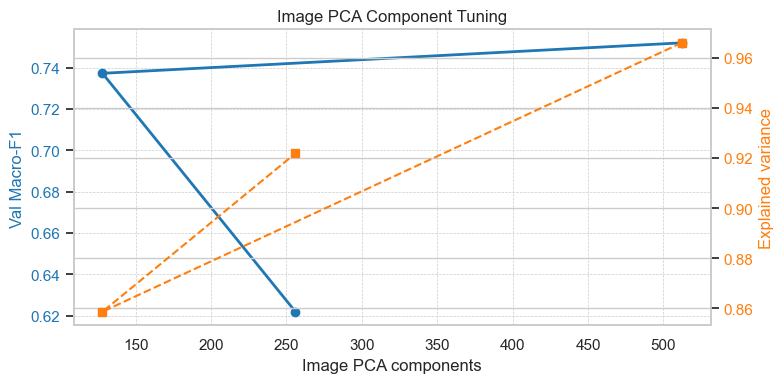

Best PCA setting: 512 components | Val Macro-F1 = 0.7519 | Explained variance = 0.9660


In [ ]:
# ── 4.1.3  Tune image PCA dimensionality (128 / 256 / 512) ──
pca_tuning_results = []
pca_feature_sets = {}

for n_comp in [128, 256, 512]:
    X_train_pca_fs, X_val_pca_fs, pca_feat_names, explained_var = build_feature_selection_dataset(
        img_pca_components=n_comp,
        rad_keep_cols=rad_keep_cols
    )
    pca_feature_sets[n_comp] = (X_train_pca_fs, X_val_pca_fs, pca_feat_names)

    result = evaluate_feature_subset(
        X_train_pca_fs,
        X_val_pca_fs,
        y_train,
        y_val,
        f'PCA-{n_comp} + all non-image features'
    )
    result['pca_components'] = n_comp
    result['img_explained_var'] = explained_var
    pca_tuning_results.append(result)

pca_tuning_summary = pd.DataFrame(pca_tuning_results).sort_values(
    'val_macro_f1',
    ascending=False
).reset_index(drop=True)

print('PCA TUNING SUMMARY')
display(pca_tuning_summary.style.format({
    'cv_mean': '{:.4f}',
    'cv_std': '{:.4f}',
    'val_macro_f1': '{:.4f}',
    'img_explained_var': '{:.4f}'
}))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(
    pca_tuning_summary['pca_components'],
    pca_tuning_summary['val_macro_f1'],
    marker='o',
    linewidth=2,
    color='tab:blue',
    label='Val Macro-F1'
)
ax1.set_xlabel('Image PCA components')
ax1.set_ylabel('Val Macro-F1', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(visible=True, linestyle='--', linewidth=0.5)

ax2 = ax1.twinx()
ax2.plot(
    pca_tuning_summary['pca_components'],
    pca_tuning_summary['img_explained_var'],
    marker='s',
    linestyle='--',
    color='tab:orange',
    label='Explained variance'
)
ax2.set_ylabel('Explained variance', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax1.set_title('Image PCA Component Tuning')
plt.tight_layout()
plt.show()

best_pca_config = pca_tuning_summary.iloc[0].to_dict()
print(f"Best PCA setting: {int(best_pca_config['pca_components'])} components | "
      f"Val Macro-F1 = {best_pca_config['val_macro_f1']:.4f} | "
      f"Explained variance = {best_pca_config['img_explained_var']:.4f}")

## 4.1.4 Optimization Schemes to SVM-RBF

Since `SVM-RBF` was the strongest early-fusion baseline in Section 3, we re-run the same feature-space optimization ideas under the same SVM hyperparameters:
- de-correlated radiomics
- `L1 / RF / MI` feature ranking
- image PCA dimensionality (`128 / 256 / 512`)

This lets us test whether the improvements observed with `LightGBM` also help the best-performing baseline model.

In [ ]:
# ── 4.1.4  Re-run the same optimization schemes with SVM-RBF ──
def build_feature_selection_dataset_with_test(img_pca_components=256, rad_keep_cols=None):
    n_comp = min(img_pca_components, X_img_train.shape[0], X_img_train.shape[1])
    pca = PCA(n_components=n_comp, random_state=SEED)
    X_img_train_fs = pca.fit_transform(X_img_train)
    X_img_val_fs = pca.transform(X_img_val)
    X_img_test_fs = pca.transform(X_img_test)
    img_feat_names = [f'img_pc{i}' for i in range(n_comp)]

    if rad_keep_cols is None:
        rad_keep_cols = rad_feat_names
    rad_keep_idx = [rad_feat_names.index(c) for c in rad_keep_cols]

    X_rad_train_fs = X_rad_train[:, rad_keep_idx]
    X_rad_val_fs = X_rad_val[:, rad_keep_idx]
    X_rad_test_fs = X_rad_test[:, rad_keep_idx]

    X_train_fs = np.hstack([X_img_train_fs, X_rad_train_fs, X_clin_train, X_text_train])
    X_val_fs = np.hstack([X_img_val_fs, X_rad_val_fs, X_clin_val, X_text_val])
    X_test_fs = np.hstack([X_img_test_fs, X_rad_test_fs, X_clin_test, X_text_test])
    feat_names = img_feat_names + list(rad_keep_cols) + clin_feat_names + text_feat_names
    explained_var = pca.explained_variance_ratio_.sum()
    return X_train_fs, X_val_fs, X_test_fs, feat_names, explained_var



def evaluate_feature_subset_svm(X_train_sel, X_val_sel, y_train, y_val, name, base_model=None, run_cv=True):
    if base_model is None:
        base_model = clone(svm)

    model = clone(base_model)
    scaler_fs = StandardScaler()
    X_train_sel_scaled = scaler_fs.fit_transform(X_train_sel)
    X_val_sel_scaled = scaler_fs.transform(X_val_sel)
    model.fit(X_train_sel_scaled, y_train)
    y_pred = model.predict(X_val_sel_scaled)
    y_proba = model.predict_proba(X_val_sel_scaled) if hasattr(model, 'predict_proba') else None

    result = {
        'name': name,
        'n_features': X_train_sel.shape[1],
        'accuracy': accuracy_score(y_val, y_pred),
        'val_macro_f1': f1_score(y_val, y_pred, average='macro'),
        'val_weighted_f1': f1_score(y_val, y_pred, average='weighted'),
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': model,
        'scaler': scaler_fs,
    }

    if run_cv:
        cv_pipe = make_pipeline(StandardScaler(), clone(base_model))
        cv_scores = cross_val_score(
            cv_pipe,
            X_train_sel,
            y_train,
            cv=skf,
            scoring='f1_macro',
            n_jobs=-1,
        )
        result['cv_scores'] = cv_scores
        result['cv_mean'] = cv_scores.mean()
        result['cv_std'] = cv_scores.std()

    return result


svm_opt_feature_sets = {
    'Baseline early fusion (800-d)': {
        'train': X_train_all,
        'val': X_val_all,
        'test': X_test_all,
        'n_features': X_train_all.shape[1],
    }
}

X_train_fs_svm, X_val_fs_svm, X_test_fs_svm, fs_feat_names_svm, fs_explained_var_svm = build_feature_selection_dataset_with_test(
    img_pca_components=256,
    rad_keep_cols=rad_keep_cols,
)
svm_opt_feature_sets['All features (de-correlated rad)'] = {
    'train': X_train_fs_svm,
    'val': X_val_fs_svm,
    'test': X_test_fs_svm,
    'n_features': X_train_fs_svm.shape[1],
}

for k in [64, 128, 256]:
    for method, ranking in [('L1', l1_ranking), ('RF', rf_ranking), ('MI', mi_ranking)]:
        selected_idx = ranking[:min(k, len(ranking))]
        svm_opt_feature_sets[f'{method} top-{len(selected_idx)}'] = {
            'train': X_train_fs_svm[:, selected_idx],
            'val': X_val_fs_svm[:, selected_idx],
            'test': X_test_fs_svm[:, selected_idx],
            'n_features': len(selected_idx),
        }

if len(l1_nonzero_idx) > 0:
    svm_opt_feature_sets[f'L1 non-zero ({len(l1_nonzero_idx)})'] = {
        'train': X_train_fs_svm[:, l1_nonzero_idx],
        'val': X_val_fs_svm[:, l1_nonzero_idx],
        'test': X_test_fs_svm[:, l1_nonzero_idx],
        'n_features': len(l1_nonzero_idx),
    }

for n_comp in [128, 256, 512]:
    X_train_pca_svm, X_val_pca_svm, X_test_pca_svm, _, explained_var = build_feature_selection_dataset_with_test(
        img_pca_components=n_comp,
        rad_keep_cols=rad_keep_cols,
    )
    svm_opt_feature_sets[f'PCA-{n_comp} + all non-image features'] = {
        'train': X_train_pca_svm,
        'val': X_val_pca_svm,
        'test': X_test_pca_svm,
        'n_features': X_train_pca_svm.shape[1],
        'img_explained_var': explained_var,
    }

svm_opt_results = {}
for name, split_data in svm_opt_feature_sets.items():
    svm_opt_results[name] = evaluate_feature_subset_svm(
        split_data['train'],
        split_data['val'],
        y_train,
        y_val,
        name,
        base_model=svm,
        run_cv=True,
    )

svm_baseline_val = early_detail['SVM-RBF']['macro_f1']
svm_baseline_cv = early_detail['SVM-RBF']['cv_mean']

svm_opt_summary = pd.DataFrame([
    {
        'name': name,
        'n_features': res['n_features'],
        'val_macro_f1': res['val_macro_f1'],
        'val_accuracy': res['accuracy'],
        'val_weighted_f1': res['val_weighted_f1'],
        'cv_mean': res.get('cv_mean', np.nan),
        'cv_std': res.get('cv_std', np.nan),
        'delta_val_vs_baseline': res['val_macro_f1'] - svm_baseline_val,
        'delta_cv_vs_baseline': res.get('cv_mean', np.nan) - svm_baseline_cv,
        'img_explained_var': svm_opt_feature_sets[name].get('img_explained_var', np.nan),
    }
    for name, res in svm_opt_results.items()
]).sort_values(['val_macro_f1', 'cv_mean'], ascending=False).reset_index(drop=True)

print('SVM-RBF OPTIMIZATION SUMMARY')
print(f'Baseline SVM-RBF from Section 3.1.3 -> CV Macro-F1 = {svm_baseline_cv:.4f}, Val Macro-F1 = {svm_baseline_val:.4f}')
display(svm_opt_summary.style.format({
    'val_macro_f1': '{:.4f}',
    'val_accuracy': '{:.4f}',
    'val_weighted_f1': '{:.4f}',
    'cv_mean': '{:.4f}',
    'cv_std': '{:.4f}',
    'delta_val_vs_baseline': '{:+.4f}',
    'delta_cv_vs_baseline': '{:+.4f}',
    'img_explained_var': '{:.4f}',
}))

best_svm_opt_name = svm_opt_summary.iloc[0]['name']
best_svm_opt_result = svm_opt_results[best_svm_opt_name]
print(f"\nBest SVM-RBF feature config: {best_svm_opt_name} | "
      f"{int(best_svm_opt_result['n_features'])} features | "
      f"Val Macro-F1 = {best_svm_opt_result['val_macro_f1']:.4f}")

svm_rbf_optimized_model_name = None
optimized_test_matrices = globals().get('optimized_test_matrices', {})

if best_svm_opt_name != 'Baseline early fusion (800-d)':
    svm_rbf_optimized_model_name = f'SVM-RBF (Optimized 4.1: {best_svm_opt_name})'
    early_detail[svm_rbf_optimized_model_name] = {
        'macro_f1': best_svm_opt_result['val_macro_f1'],
        'accuracy': best_svm_opt_result['accuracy'],
        'weighted_f1': best_svm_opt_result['val_weighted_f1'],
        'y_pred': best_svm_opt_result['y_pred'],
        'y_proba': best_svm_opt_result['y_proba'],
        'cv_scores': best_svm_opt_result['cv_scores'],
        'cv_mean': best_svm_opt_result['cv_mean'],
        'cv_std': best_svm_opt_result['cv_std'],
        'model': best_svm_opt_result['model'],
        'scaler': best_svm_opt_result['scaler'],
        'feature_config': best_svm_opt_name,
    }
    early_results[svm_rbf_optimized_model_name] = best_svm_opt_result['val_macro_f1']
    if 'all_detail' in globals():
        all_detail[svm_rbf_optimized_model_name] = early_detail[svm_rbf_optimized_model_name]
    optimized_test_matrices[svm_rbf_optimized_model_name] = best_svm_opt_result['scaler'].transform(
        svm_opt_feature_sets[best_svm_opt_name]['test']
    )
    print(f'Added {svm_rbf_optimized_model_name} to downstream model comparison.')
else:
    print('No optimized SVM-RBF feature configuration outperformed the original 800-d baseline on validation Macro-F1.')


/opt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


SVM-RBF OPTIMIZATION SUMMARY
Baseline SVM-RBF from Section 3.1.3 -> CV Macro-F1 = 0.7029, Val Macro-F1 = 0.7834


,name,n_features,val_macro_f1,val_accuracy,val_weighted_f1,cv_mean,cv_std,delta_val_vs_baseline,delta_cv_vs_baseline,img_explained_var
0,L1 top-128,128,0.7853,0.8339,0.8335,0.7344,0.0301,+0.0018,+0.0315,nan
1,All features (de-correlated rad),796,0.7834,0.8587,0.8581,0.7038,0.0371,+0.0000,+0.0009,nan
2,PCA-256 + all non-image features,796,0.7834,0.8587,0.8581,0.7038,0.0371,+0.0000,+0.0009,0.9218
3,Baseline early fusion (800-d),800,0.7834,0.8587,0.8581,0.7029,0.0367,+0.0000,+0.0000,nan
4,L1 top-256,256,0.7790,0.8269,0.8258,0.7529,0.0308,-0.0045,+0.0499,nan
5,PCA-512 + all non-image features,1052,0.7719,0.8587,0.8555,0.6397,0.0415,-0.0116,-0.0633,0.9660
6,PCA-128 + all non-image features,668,0.7636,0.8410,0.8385,0.7286,0.0517,-0.0198,+0.0257,0.8586
7,L1 non-zero (489),489,0.7358,0.8410,0.8391,0.7064,0.0455,-0.0477,+0.0035,nan
8,RF top-128,128,0.7253,0.7809,0.7803,0.6562,0.0285,-0.0581,-0.0467,nan
9,MI top-256,256,0.6935,0.8410,0.8352,0.7365,0.0436,-0.0900,+0.0336,nan



Best SVM-RBF feature config: L1 top-128 | 128 features | Val Macro-F1 = 0.7853
Added SVM-RBF (Optimized 4.1: L1 top-128) to downstream model comparison.


## 4.1.5 Optimization Schemes to XGBoost

We also transfer the same 4.1 feature-space optimization schemes to `XGBoost`, since it was another strong early-fusion model in Section 3.

This comparison tests whether the best feature subsets for `LightGBM` or `SVM-RBF` also improve boosting-based multiclass classification under the same `XGBoost` hyperparameters.

In [ ]:
# ── 4.1.5  Re-run the same optimization schemes with XGBoost ──
def evaluate_feature_subset_xgb(X_train_sel, X_val_sel, y_train, y_val, name, base_model=None, run_cv=True):
    if base_model is None:
        base_model = clone(xgb_model)

    model = clone(base_model)
    scaler_fs = StandardScaler()
    X_train_sel_scaled = scaler_fs.fit_transform(X_train_sel)
    X_val_sel_scaled = scaler_fs.transform(X_val_sel)
    model.fit(X_train_sel_scaled, y_train, sample_weight=sample_weights_train)
    y_pred = model.predict(X_val_sel_scaled)
    y_proba = model.predict_proba(X_val_sel_scaled) if hasattr(model, 'predict_proba') else None

    result = {
        'name': name,
        'n_features': X_train_sel.shape[1],
        'accuracy': accuracy_score(y_val, y_pred),
        'val_macro_f1': f1_score(y_val, y_pred, average='macro'),
        'val_weighted_f1': f1_score(y_val, y_pred, average='weighted'),
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': model,
        'scaler': scaler_fs,
    }

    if run_cv:
        cv_scores = []
        for tr_idx, va_idx in skf.split(X_train_sel, y_train):
            fold_scaler = StandardScaler()
            X_tr_fold = fold_scaler.fit_transform(X_train_sel[tr_idx])
            X_va_fold = fold_scaler.transform(X_train_sel[va_idx])
            fold_model = clone(base_model)
            fold_model.fit(X_tr_fold, y_train[tr_idx], sample_weight=sample_weights_train[tr_idx])
            fold_pred = fold_model.predict(X_va_fold)
            cv_scores.append(f1_score(y_train[va_idx], fold_pred, average='macro'))
        cv_scores = np.array(cv_scores)
        result['cv_scores'] = cv_scores
        result['cv_mean'] = cv_scores.mean()
        result['cv_std'] = cv_scores.std()

    return result


xgb_opt_feature_sets = {
    'Baseline early fusion (800-d)': {
        'train': X_train_all,
        'val': X_val_all,
        'test': X_test_all,
        'n_features': X_train_all.shape[1],
    },
    'All features (de-correlated rad)': {
        'train': X_train_fs_svm,
        'val': X_val_fs_svm,
        'test': X_test_fs_svm,
        'n_features': X_train_fs_svm.shape[1],
    },
}

for k in [64, 128, 256]:
    for method, ranking in [('L1', l1_ranking), ('RF', rf_ranking), ('MI', mi_ranking)]:
        selected_idx = ranking[:min(k, len(ranking))]
        xgb_opt_feature_sets[f'{method} top-{len(selected_idx)}'] = {
            'train': X_train_fs_svm[:, selected_idx],
            'val': X_val_fs_svm[:, selected_idx],
            'test': X_test_fs_svm[:, selected_idx],
            'n_features': len(selected_idx),
        }

if len(l1_nonzero_idx) > 0:
    xgb_opt_feature_sets[f'L1 non-zero ({len(l1_nonzero_idx)})'] = {
        'train': X_train_fs_svm[:, l1_nonzero_idx],
        'val': X_val_fs_svm[:, l1_nonzero_idx],
        'test': X_test_fs_svm[:, l1_nonzero_idx],
        'n_features': len(l1_nonzero_idx),
    }

for n_comp in [128, 256, 512]:
    X_train_pca_xgb, X_val_pca_xgb, X_test_pca_xgb, _, explained_var = build_feature_selection_dataset_with_test(
        img_pca_components=n_comp,
        rad_keep_cols=rad_keep_cols,
    )
    xgb_opt_feature_sets[f'PCA-{n_comp} + all non-image features'] = {
        'train': X_train_pca_xgb,
        'val': X_val_pca_xgb,
        'test': X_test_pca_xgb,
        'n_features': X_train_pca_xgb.shape[1],
        'img_explained_var': explained_var,
    }

xgb_opt_results = {}
for name, split_data in xgb_opt_feature_sets.items():
    xgb_opt_results[name] = evaluate_feature_subset_xgb(
        split_data['train'],
        split_data['val'],
        y_train,
        y_val,
        name,
        base_model=xgb_model,
        run_cv=True,
    )

xgb_baseline_val = early_detail['XGB']['macro_f1']
xgb_baseline_cv = early_detail['XGB']['cv_mean']

xgb_opt_summary = pd.DataFrame([
    {
        'name': name,
        'n_features': res['n_features'],
        'val_macro_f1': res['val_macro_f1'],
        'val_accuracy': res['accuracy'],
        'val_weighted_f1': res['val_weighted_f1'],
        'cv_mean': res.get('cv_mean', np.nan),
        'cv_std': res.get('cv_std', np.nan),
        'delta_val_vs_baseline': res['val_macro_f1'] - xgb_baseline_val,
        'delta_cv_vs_baseline': res.get('cv_mean', np.nan) - xgb_baseline_cv,
        'img_explained_var': xgb_opt_feature_sets[name].get('img_explained_var', np.nan),
    }
    for name, res in xgb_opt_results.items()
]).sort_values(['val_macro_f1', 'cv_mean'], ascending=False).reset_index(drop=True)

print('XGBOOST OPTIMIZATION SUMMARY')
print(f'Baseline XGB from Section 3.1.4 -> CV Macro-F1 = {xgb_baseline_cv:.4f}, Val Macro-F1 = {xgb_baseline_val:.4f}')
display(xgb_opt_summary.style.format({
    'val_macro_f1': '{:.4f}',
    'val_accuracy': '{:.4f}',
    'val_weighted_f1': '{:.4f}',
    'cv_mean': '{:.4f}',
    'cv_std': '{:.4f}',
    'delta_val_vs_baseline': '{:+.4f}',
    'delta_cv_vs_baseline': '{:+.4f}',
    'img_explained_var': '{:.4f}',
}))

best_xgb_opt_name = xgb_opt_summary.iloc[0]['name']
best_xgb_opt_result = xgb_opt_results[best_xgb_opt_name]
print(f"\nBest XGBoost feature config: {best_xgb_opt_name} | "
      f"{int(best_xgb_opt_result['n_features'])} features | "
      f"Val Macro-F1 = {best_xgb_opt_result['val_macro_f1']:.4f}")

xgb_optimized_model_name = None
optimized_test_matrices = globals().get('optimized_test_matrices', {})

if best_xgb_opt_name != 'Baseline early fusion (800-d)':
    xgb_optimized_model_name = f'XGB (Optimized 4.1: {best_xgb_opt_name})'
    early_detail[xgb_optimized_model_name] = {
        'macro_f1': best_xgb_opt_result['val_macro_f1'],
        'accuracy': best_xgb_opt_result['accuracy'],
        'weighted_f1': best_xgb_opt_result['val_weighted_f1'],
        'y_pred': best_xgb_opt_result['y_pred'],
        'y_proba': best_xgb_opt_result['y_proba'],
        'cv_scores': best_xgb_opt_result['cv_scores'],
        'cv_mean': best_xgb_opt_result['cv_mean'],
        'cv_std': best_xgb_opt_result['cv_std'],
        'model': best_xgb_opt_result['model'],
        'scaler': best_xgb_opt_result['scaler'],
        'feature_config': best_xgb_opt_name,
    }
    early_results[xgb_optimized_model_name] = best_xgb_opt_result['val_macro_f1']
    if 'all_detail' in globals():
        all_detail[xgb_optimized_model_name] = early_detail[xgb_optimized_model_name]
    optimized_test_matrices[xgb_optimized_model_name] = best_xgb_opt_result['scaler'].transform(
        xgb_opt_feature_sets[best_xgb_opt_name]['test']
    )
    print(f'Added {xgb_optimized_model_name} to downstream model comparison.')
else:
    print('No optimized XGBoost feature configuration outperformed the original 800-d baseline on validation Macro-F1.')


XGBOOST OPTIMIZATION SUMMARY
Baseline XGB from Section 3.1.4 -> CV Macro-F1 = 0.6211, Val Macro-F1 = 0.7288


,name,n_features,val_macro_f1,val_accuracy,val_weighted_f1,cv_mean,cv_std,delta_val_vs_baseline,delta_cv_vs_baseline,img_explained_var
0,MI top-256,256,0.7535,0.8587,0.8554,0.6732,0.0498,+0.0248,+0.0521,nan
1,All features (de-correlated rad),796,0.7366,0.8269,0.8227,0.6260,0.0361,+0.0078,+0.0049,nan
2,PCA-256 + all non-image features,796,0.7366,0.8269,0.8227,0.6260,0.0361,+0.0078,+0.0049,0.9218
3,Baseline early fusion (800-d),800,0.7288,0.8233,0.8171,0.6291,0.0312,+0.0000,+0.0080,nan
4,L1 non-zero (489),489,0.7164,0.8269,0.8236,0.6462,0.0398,-0.0124,+0.0251,nan
5,PCA-128 + all non-image features,668,0.7155,0.8233,0.8216,0.6699,0.0604,-0.0133,+0.0488,0.8586
6,MI top-128,128,0.7060,0.8339,0.8322,0.7198,0.0341,-0.0228,+0.0987,nan
7,RF top-128,128,0.6848,0.7880,0.7812,0.6501,0.0576,-0.0439,+0.0290,nan
8,RF top-256,256,0.6732,0.7880,0.7766,0.6378,0.0727,-0.0556,+0.0167,nan
9,RF top-64,64,0.6646,0.7420,0.7403,0.6384,0.0710,-0.0642,+0.0173,nan



Best XGBoost feature config: MI top-256 | 256 features | Val Macro-F1 = 0.7535
Added XGB (Optimized 4.1: MI top-256) to downstream model comparison.


---
# 5. Model Analysis

Targeting the workload/analysis component (40% of grade).

## 5.1 Model Comparison Summary (Early + Late Fusion)

In [ ]:
all_results = {**early_results, **late_results}

print('\n' + '=' * 70)
print('FULL MODEL COMPARISON  (CV = primary, Val = reference)')
print('=' * 70)
for name, f1 in sorted(all_results.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(f1 * 50)
    d = all_detail.get(name, {})
    cv_str = f'CV {d["cv_mean"]:.4f}±{d["cv_std"]:.4f}' if 'cv_mean' in d else '     —      '
    print(f'{name:15s} | {cv_str} | Val {f1:.4f} | {bar}')
best_name = max(all_results, key=all_results.get)
print(f'\n*** Best: {best_name} (Val Macro-F1 = {all_results[best_name]:.4f}) ***')


FULL MODEL COMPARISON  (CV = primary, Val = reference)
SVM-RBF (Optimized 4.1: L1 top-128) | CV 0.7344±0.0301 | Val 0.7853 | ███████████████████████████████████████
SVM-RBF         | CV 0.7029±0.0367 | Val 0.7834 | ███████████████████████████████████████
Soft Voting     |      —       | Val 0.7816 | ███████████████████████████████████████
XGB (Optimized 4.1: MI top-256) | CV 0.6732±0.0498 | Val 0.7535 | █████████████████████████████████████
XGB             | CV 0.6211±0.0496 | Val 0.7288 | ████████████████████████████████████
PyTorch Multi-Branch MLP | CV 0.7417±0.0313 | Val 0.7186 | ███████████████████████████████████
MLP             | CV 0.7255±0.0251 | Val 0.7051 | ███████████████████████████████████
LR (L2)         | CV 0.6941±0.0523 | Val 0.7039 | ███████████████████████████████████
LGB             | CV 0.6280±0.0298 | Val 0.6268 | ███████████████████████████████

*** Best: SVM-RBF (Optimized 4.1: L1 top-128) (Val Macro-F1 = 0.7853) ***


## 5.2 Modality Ablation Study

In [ ]:
feature_groups = {
    'Image Only':       (X_img_train_pca, X_img_val_pca),
    'Radiomics Only':   (X_rad_train, X_rad_val),
    'Clinical Only':    (X_clin_train, X_clin_val),
    'Text Only':        (X_text_train, X_text_val),
    'Img+Rad':          (np.hstack([X_img_train_pca, X_rad_train]), np.hstack([X_img_val_pca, X_rad_val])),
    'Img+Clin':         (np.hstack([X_img_train_pca, X_clin_train]), np.hstack([X_img_val_pca, X_clin_val])),
    'Img+Text':         (np.hstack([X_img_train_pca, X_text_train]), np.hstack([X_img_val_pca, X_text_val])),
    'All (Early Fusion)': (X_train_all, X_val_all),
}

ablation = {}
for name, (Xtr, Xva) in feature_groups.items():
    sc = StandardScaler()
    m = lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                           class_weight='balanced', random_state=SEED, verbose=-1)
    m.fit(sc.fit_transform(Xtr), y_train)
    ablation[name] = f1_score(y_val, m.predict(sc.transform(Xva)), average='macro')

print('\nMODALITY ABLATION (LightGBM, Macro-F1)')
print('='*45)
for name, f1 in sorted(ablation.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name:22s} | {f1:.4f}')


MODALITY ABLATION (LightGBM, Macro-F1)
  Text Only              | 0.7027
  Clinical Only          | 0.6688
  All (Early Fusion)     | 0.6223
  Img+Text               | 0.5575
  Img+Clin               | 0.5469
  Img+Rad                | 0.3099
  Image Only             | 0.2999
  Radiomics Only         | 0.2899


## 5.3 Feature Importance & Interpretability (Tutorial 7/8 Style)

We compare feature importances from two tree-based models (Random Forest and LightGBM) to identify the most discriminative features. Additional SHAP analysis can be added during the report writing phase.

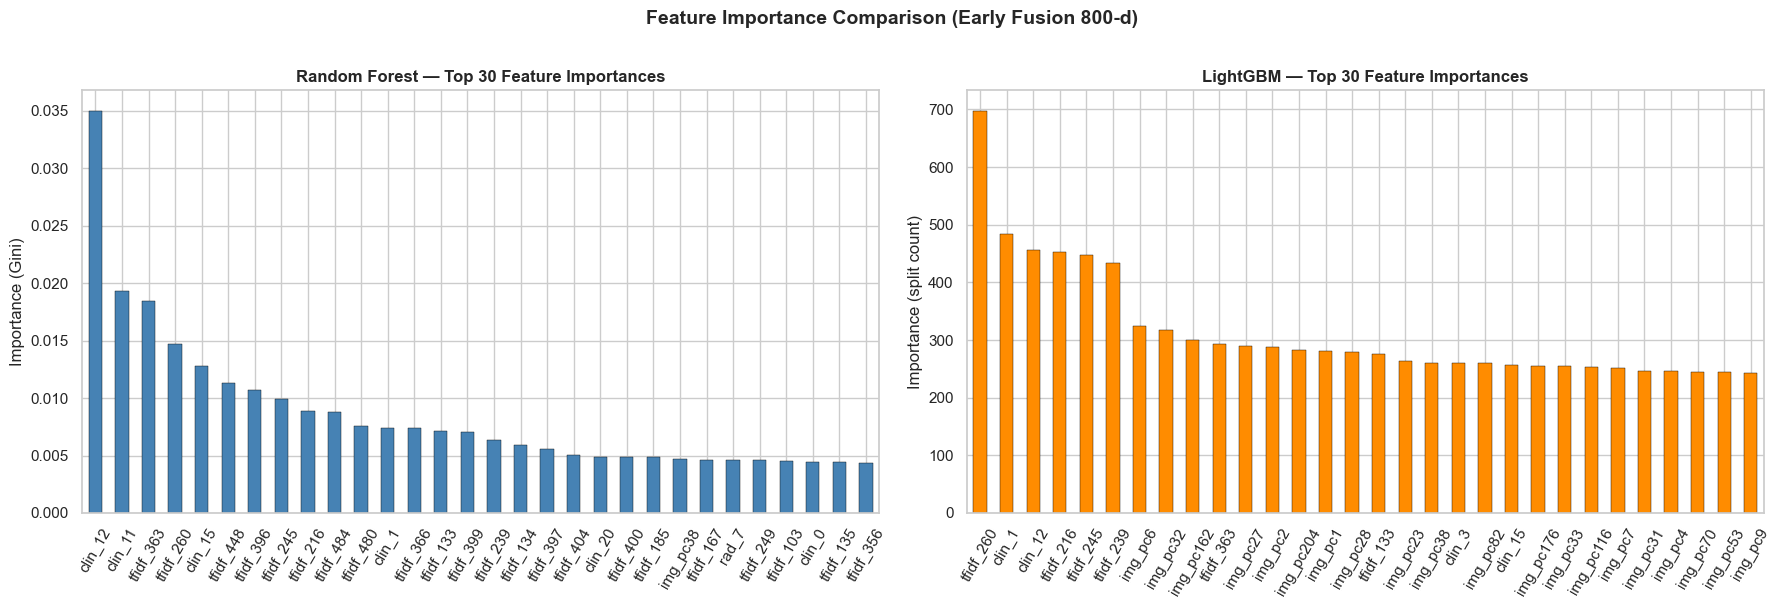


Feature source breakdown in RF Top-30:
  Image       : 1/30
  Radiomics   : 1/30
  Clinical    : 6/30
  Text        : 22/30

Feature source breakdown in LGB Top-30:
  Image       : 20/30
  Radiomics   : 0/30
  Clinical    : 4/30
  Text        : 6/30


In [ ]:
# ── 5.3.1  Build feature name list matching the 800-d concatenated vector ──
img_names  = [f'img_pc{i}' for i in range(X_img_train_pca.shape[1])]
rad_names  = [f'rad_{c}' for c in range(X_rad_train.shape[1])]
clin_names = [f'clin_{i}' for i in range(X_clin_train.shape[1])]
text_names = [f'tfidf_{i}' for i in range(X_text_train.shape[1])]
all_feat_names = img_names + rad_names + clin_names + text_names

# ── 5.3.2  Random Forest — Top 30 feature importances ──
rf_imp = pd.Series(rf.feature_importances_, index=all_feat_names).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

rf_imp.head(30).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black', linewidth=0.3)
axes[0].set_title('Random Forest — Top 30 Feature Importances', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Importance (Gini)')
axes[0].tick_params(axis='x', rotation=60)

# ── 5.3.3  LightGBM — Top 30 feature importances ──
lgb_imp = pd.Series(lgb_model.feature_importances_, index=all_feat_names).sort_values(ascending=False)
lgb_imp.head(30).plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black', linewidth=0.3)
axes[1].set_title('LightGBM — Top 30 Feature Importances', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Importance (split count)')
axes[1].tick_params(axis='x', rotation=60)

plt.suptitle('Feature Importance Comparison (Early Fusion 800-d)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# modality breakdown
print('\nFeature source breakdown in RF Top-30:')
top30_rf = rf_imp.head(30).index
for prefix, label in [('img_', 'Image'), ('rad_', 'Radiomics'), ('clin_', 'Clinical'), ('tfidf_', 'Text')]:
    count = sum(1 for f in top30_rf if f.startswith(prefix))
    print(f'  {label:12s}: {count}/30')

print('\nFeature source breakdown in LGB Top-30:')
top30_lgb = lgb_imp.head(30).index
for prefix, label in [('img_', 'Image'), ('rad_', 'Radiomics'), ('clin_', 'Clinical'), ('tfidf_', 'Text')]:
    count = sum(1 for f in top30_lgb if f.startswith(prefix))
    print(f'  {label:12s}: {count}/30')

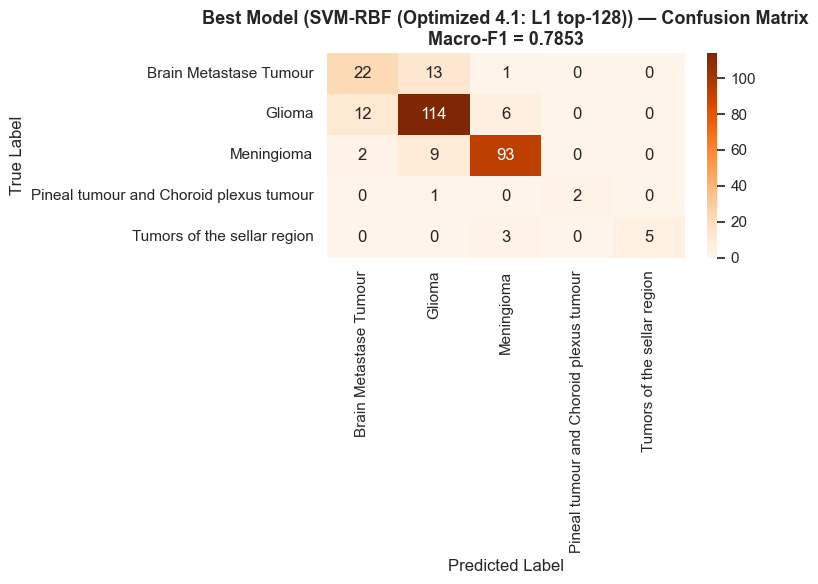


Most confused class pairs (off-diagonal max):
                    Brain Metastase Tumour → predicted as Glioma                         (13 cases)
                                    Glioma → predicted as Brain Metastase Tumour         (12 cases)
                                Meningioma → predicted as Glioma                         (9 cases)


In [ ]:
# ── 5.3.4  Confusion matrix of the BEST model (error analysis) ──
best_detail = all_detail[best_name]
cm_best = confusion_matrix(y_val, best_detail['y_pred'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=ax)
ax.set_title(f'Best Model ({best_name}) — Confusion Matrix\n'
             f'Macro-F1 = {best_detail["macro_f1"]:.4f}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f'\nMost confused class pairs (off-diagonal max):')
np.fill_diagonal(cm_best, 0)
for _ in range(3):
    r, c = np.unravel_index(cm_best.argmax(), cm_best.shape)
    print(f'  {label_encoder.classes_[r]:>40s} → predicted as '
          f'{label_encoder.classes_[c]:<30s} ({cm_best[r, c]} cases)')
    cm_best[r, c] = 0

---
# 6. Generate Kaggle Submission

In [ ]:
model_map = {'LR (L2)': lr, 'RF': rf, 'SVM-RBF': svm, 'XGB': xgb_model,
             'LGB': lgb_model, 'MLP': mlp,
             'Soft Voting': voting_clf, 'Stacking': stacking_clf}
if 'svm_rbf_optimized_model_name' in globals() and svm_rbf_optimized_model_name is not None:
    model_map[svm_rbf_optimized_model_name] = early_detail[svm_rbf_optimized_model_name]['model']
if 'xgb_optimized_model_name' in globals() and xgb_optimized_model_name is not None:
    model_map[xgb_optimized_model_name] = early_detail[xgb_optimized_model_name]['model']

best_model = model_map[best_name]
print(f'Using best model: {best_name}')

optimized_test_matrices = globals().get('optimized_test_matrices', {})
X_test_for_best = optimized_test_matrices.get(best_name, X_test_scaled)
y_test_pred = best_model.predict(X_test_for_best)
submission = pd.DataFrame({'case_id': [int(c) for c in test_ids],
                           'Overall_class': label_encoder.inverse_transform(y_test_pred)})
sample_sub = pd.read_csv(TEST_ROOT / 'sample_submission.csv')
submission = submission.set_index('case_id').loc[sample_sub['case_id']].reset_index()
assert len(submission) == len(sample_sub), (
    f'Got {len(submission)} rows but sample_submission has {len(sample_sub)} — '
    'regenerate after updating dataset (test set size changed).'
)
sub_path = Path.cwd() / 'submission.csv'
for d in [Path.cwd(), *Path.cwd().resolve().parents]:
    nd = d / 'notebooks'
    if not nd.is_dir():
        continue
    if (nd / 'pipeline_macro_0418.ipynb').is_file() or (nd / 'pipeline_macro.ipynb').is_file() or (nd / 'pipeline_micro.ipynb').is_file():
        sub_path = nd / 'submission.csv'
        break
submission.to_csv(sub_path, index=False)

print(f'\nWrote: {sub_path.resolve()}')
print(f'Submission saved ({len(submission)} rows; must match Kaggle test count). Distribution:')
print(submission['Overall_class'].value_counts())

Using best model: SVM-RBF (Optimized 4.1: L1 top-128)


KeyError: "None of [Index([   1,    5,    9,   14,   35,   48,   50,   52,   55,   58,\n       ...\n       2921, 2925, 2930, 2934, 2936, 2937, 2938, 2943, 2944, 2950],\n      dtype='int64', name='case_id', length=572)] are in the [index]"